# Tardis Project

We, Loup, Lukas, and Eva, are part of a newly formed **SNCF Data Analysis Service**, dedicated to improving the efficiency of train travel across the country.

Our mission? Analyze historical train delay data, uncover hidden patterns, and develop a predictive model that can forecast delays before they happen. The SNCF has entrusted our team with making the railway system more efficient and transparent.

If we <span style="color:green">succeed</span>, our dashboard will be used by thousands of travelers to better plan their journeys. If we <span style="color:red">fail</span>... well, we expect a lot more unhappy commuters. 

No pressure! Using the provided dataset, our job is to clean and analyze historical delay data, develop a simple predictive model, and present our insights through an interactive **Streamlit dashboard**.

In [3580]:
# Importing the libraries to manage the dataset and visualize data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3581]:
# --- CLEANING UTILITY FUNCTIONS ---

def clean_numeric_column(df, column_name, text_to_remove=None, to_type='float'):
    """
    Cleans a column surgically.
    Extracts the first valid numeric sequence found in the cell.
    """
    if column_name not in df.columns:
        return df

    # 1. Prepare work buffer as string
    processed_col = df[column_name].astype(str)

    # 2. Remove specific text if provided ("min")
    if text_to_remove is not None:
        processed_col = processed_col.str.replace(text_to_remove, "", regex=False)

    # 3. Normalization (commas -> dots, strip spaces)
    processed_col = processed_col.str.replace(",", ".", regex=False).str.strip()

    # 4. Pattern: [optional sign] [digits] [optional dot] [digits]
    processed_col = processed_col.str.extract(r'([-+]?\d*\.?\d+)')[0]

    # 5. Final conversion (errors='raise' to guarantee cleaning quality and catch errors)
    df[column_name] = pd.to_numeric(processed_col, errors='raise')

    # 6. Final typing
    if to_type == 'int':
        df[column_name] = df[column_name].round().astype('Int64')
    else:
        df[column_name] = df[column_name].astype(float)

    return df

def drop_invalid_rows(df, column_name):
    """ Removes rows where the value is null or unusable. """
    return df.dropna(subset=[column_name])

# Step 1: Data Exploration and Cleaning
## 1. Loading the Dataset

Examining column names, count, and data types.

In [3582]:
df = pd.read_csv("dataset.csv", sep=";")

# Rename long column name for better readability
df = df.rename(columns={'Pct delay due to passenger handling (crowding, disabled persons, connections)': 'Pct delay due to passenger handling'})

df_raw = df.copy() # Keep a copy of the raw data for the final efficiency visualization
print("Column names and types:")

# Displaying column types
for col in df.columns:
    print(f"{col} -> {df[col].dtype}")

Column names and types:
Date -> str
Service -> str
Departure station -> str
Arrival station -> str
Average journey time -> str
Number of scheduled trains -> str
Number of cancelled trains -> str
Cancellation comments -> str
Number of trains delayed at departure -> str
Average delay of late trains at departure -> str
Average delay of all trains at departure -> str
Departure delay comments -> str
Number of trains delayed at arrival -> str
Average delay of late trains at arrival -> str
Average delay of all trains at arrival -> str
Arrival delay comments -> str
Number of trains delayed > 15min -> str
Average delay of trains > 15min (if competing with flights) -> str
Number of trains delayed > 30min -> str
Number of trains delayed > 60min -> str
Pct delay due to external causes -> str
Pct delay due to infrastructure -> str
Pct delay due to traffic management -> str
Pct delay due to rolling stock -> str
Pct delay due to station management and equipment reuse -> str
Pct delay due to passenger

### Initial Data Inspection
We examine raw dataset statistics and preview the data.

In [3583]:
display(df.describe())

print("\nInitial dataset preview:")
display(df.head())

nb_line_start, nb_col_start = df.shape
print(f"\nThe original dataset contains {nb_col_start} columns and {nb_line_start} rows.")

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,Pct delay due to passenger handling
count,12010,11830,12011,12011,11830,11830,11831,577,11830,11831,...,11828,11831,11832,11833,11828,11827,11829,11827,11828,11830
unique,318,2,132,116,651,1034,248,3,629,11162,...,265,11075,175,96,2732,2592,2677,2535,2130,2172
top,2025-09,National,PARIS LYON,PARIS LYON,96.0,31.0,0.0,Non communiqué,13.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
freq,135,10370,2405,2413,184,117,3917,196,161,134,...,327,218,779,1760,1100,1021,1326,1220,3361,3809



Initial dataset preview:


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,Pct delay due to passenger handling
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,...,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,...,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965



The original dataset contains 26 columns and 12070 rows.


### Visualizing Missing Values
Before cleaning, we identify missing values in the raw data using a heatmap.

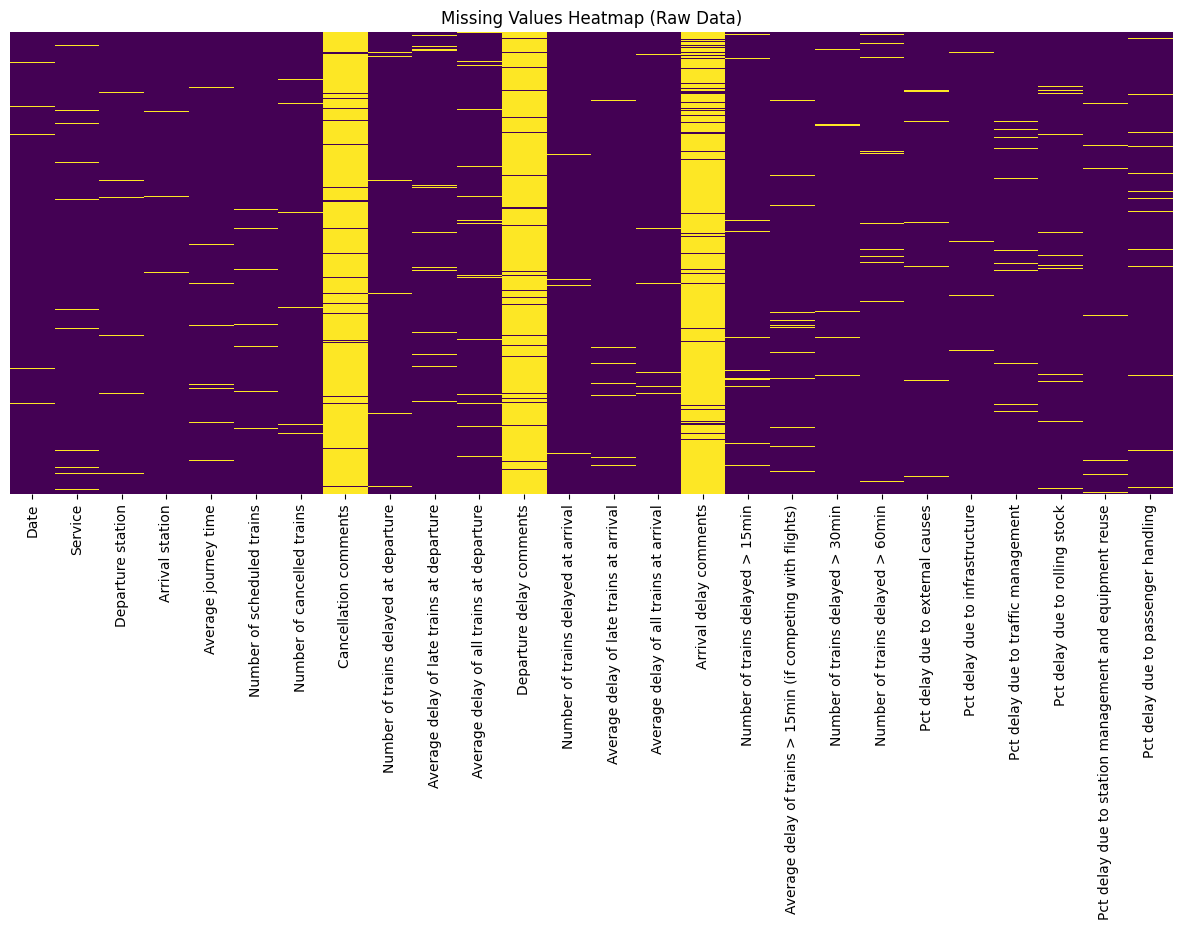

In [3584]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Raw Data)')
plt.show()

## 2. Duplicate Removal
We remove identical rows to ensure data integrity.

In [3585]:
df = df.drop_duplicates()

nb_line_after_dupes, _ = df.shape
print(f"Rows after duplicate removal: {nb_line_after_dupes} ({nb_line_start - nb_line_after_dupes} rows removed).")

Rows after duplicate removal: 11896 (174 rows removed).


## 3. Data Cleaning and Column Formatting

### Date Column
We standardize the `Date` column and extract `Year` and `Month` features.

In [3586]:
# 1. Convert to datetime and standardize format
df['Date'] = pd.to_datetime(df['Date'], yearfirst=True, format='mixed')

# 2. Smart Fix: if a date is missing but the previous and next lines have the same date,
# we assume the missing date is the same.
date_coll = df['Date']
for i in range(1, len(df) - 1):
    if pd.isnull(date_coll.iloc[i]):
        if date_coll.iloc[i-1] == date_coll.iloc[i+1]:
            df.loc[df.index[i], 'Date'] = date_coll.iloc[i-1]

# 3. Drop remaining rows with missing dates (critical for analysis)
df = drop_invalid_rows(df, 'Date')

# 4. Extract Year and Month, then drop the original Date column
df['Year'] = df['Date'].dt.year.astype(int)
df['Month'] = df['Date'].dt.month.astype(int)
df = df.drop(columns=['Date'])

# 5. Place the Year and Month columns at the beginning of the DataFrame
cols = df.columns.tolist()
cols.remove('Year')
cols.remove('Month')
df = df[['Year', 'Month'] + cols]

print(f"Remaining rows after date validation: {len(df)}")
display(df[['Year', 'Month']].head())

Remaining rows after date validation: 11895


,Year,Month
0,2018,1
1,2018,1
2,2018,1
3,2018,1
4,2018,1


### Season Feature
We create a `Season` column based on the month.

In [3587]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    if month in [3, 4, 5]:
        return 'Spring'
    if month in [6, 7, 8]:
        return 'Summer'
    return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

#Place the Season column after Month
cols = df.columns.tolist()
cols.remove('Year')
cols.remove('Month')
cols.remove('Season')
df = df[['Year', 'Month', 'Season'] + cols]

display(df[['Month', 'Season']].head())

,Month,Season
0,1,Winter
1,1,Winter
2,1,Winter
3,1,Winter
4,1,Winter


### Service Column
We ensure the `Service` column only contains 'National' or 'International' values. Other values are set to `NaN`.

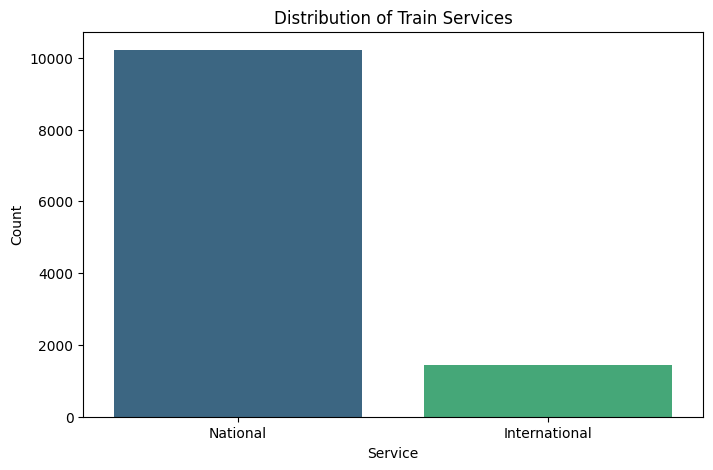

Rows with missing or invalid Service values: 240
Service counts:
Service
National         10216
International     1439
Name: count, dtype: int64


In [3588]:
# List of valid service categories for the SNCF network
valid_services = ['national', 'international']

# 1. Convert to lowercase and strip whitespace for uniform comparison
df['Service'] = df['Service'].str.lower().str.strip()

# 2. Apply a transformation to each cell using a 'lambda' function:
# - If the value is valid, capitalize it ('national' -> 'National')
# - If the value is invalid/unknown, set it to 'pd.NA' (Missing Value)
df['Service'] = df['Service'].apply(lambda x: x.capitalize() if x in valid_services else pd.NA)

def find_service(row, catalog):
    # If the service is already provided, keep it
    if not pd.isna(row['Service']):
        return row['Service']
    
    # Otherwise, look for a "donor line" in our catalog with the same journey
    donor = catalog[
        (catalog['Departure station'] == row['Departure station']) &
        (catalog['Arrival station'] == row['Arrival station'])
    ]
    
    # If a donor is found, take its service
    if not donor.empty:
        return donor['Service'].iloc[0]
    
    # If nothing is found, keep it as NaN
    return pd.NA

# Visualize the distribution of service types to understand dataset balance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Service', hue='Service', palette='viridis', legend=False)
plt.title('Distribution of Train Services')
plt.ylabel('Count')
plt.show()

print(f"Rows with missing or invalid Service values: {df['Service'].isna().sum()}")
print("Service counts:")
print(df['Service'].value_counts())

### Departure and Arrival Stations
We convert station names to uppercase and remove rows with missing station information.

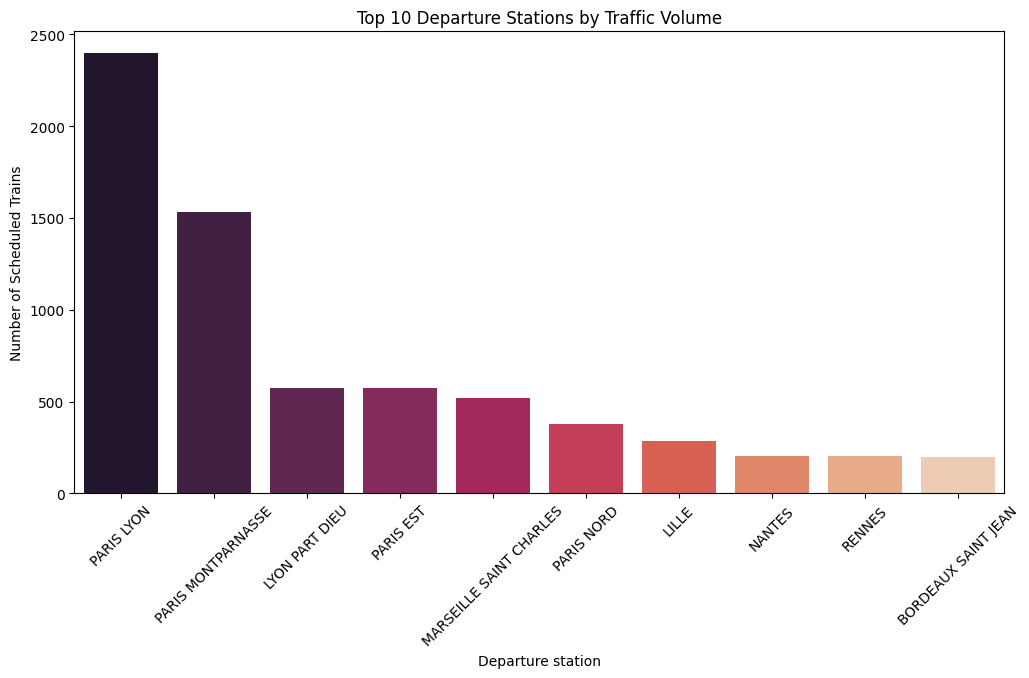

Service               2
Departure station    59
Arrival station      59
Season                4
dtype: int64

Final count after station validation: 11761


In [3589]:
for col in ['Departure station', 'Arrival station']:
    # Standardize to uppercase and strip spaces
    df[col] = df[col].str.upper().str.strip()

    #Replace ST mention to SAINT
    df[col] = df[col].str.replace('ST ', 'SAINT ')

    # Replace null values with Pandas NA
    df[col] = df[col].replace(["NAN", "NULL", "0"], pd.NA)

    # Remove rows where station name is missing
    df = drop_invalid_rows(df, col)

# Create a "catalog" of known journeys
known_journeys = df.dropna(subset=['Service']).drop_duplicates(subset=['Departure station', 'Arrival station'])

# Attempt to fill missing Service values using the catalog of known journeys
df['Service'] = df.apply(lambda row: find_service(row, known_journeys), axis=1)

# Visualize Top 10 most frequent Departure Stations
plt.figure(figsize=(12, 6))
top_stations = df['Departure station'].value_counts().nlargest(10)
sns.barplot(x=top_stations.index, y=top_stations.values, hue=top_stations.index, palette='rocket', legend=False)
plt.title('Top 10 Departure Stations by Traffic Volume')
plt.xticks(rotation=45)
plt.ylabel('Number of Scheduled Trains')
plt.show()

print(df[['Service', 'Departure station', 'Arrival station', 'Season']].nunique())
print(f"\nFinal count after station validation: {len(df)}")

### Column Cleanup
We remove columns that contain no data or are not useful for our analysis to streamline the dataset.

In [3590]:
# Drop unused comment columns and any other redundant data
cols_to_drop = ['Departure delay comments', 'Arrival delay comments', 'Cancellation comments']
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {len(df.columns)}")

Dropped columns: ['Departure delay comments', 'Arrival delay comments', 'Cancellation comments']
Remaining columns: 25


### Average Journey Time
We clean the journey time by removing the 'min' text and converting the values to integers. Missing values are kept as `NaN`.

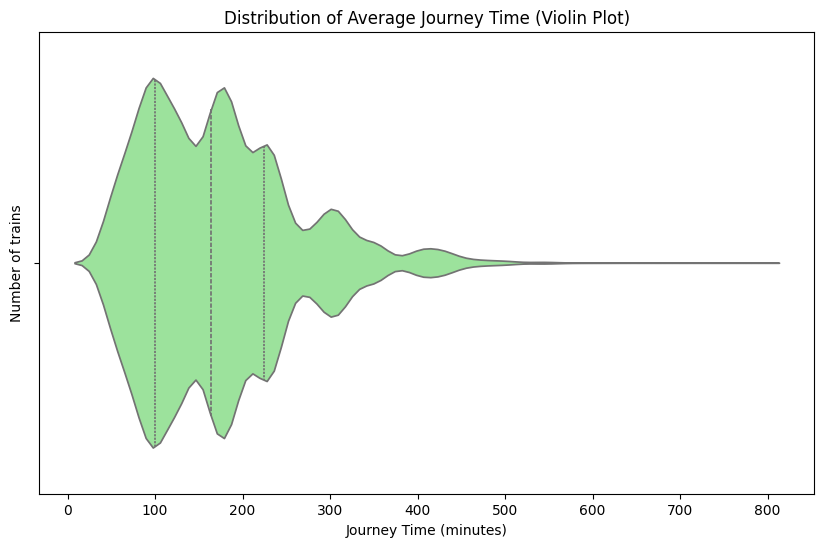

Missing values in Average journey time: 0


In [3591]:
# Clean numeric data: remove 'min', handle commas, and convert to Integer
df = clean_numeric_column(df, 'Average journey time', text_to_remove='min', to_type='int')

# Drop line if value is NaN or zero
for col in ['Average journey time']:
    df.dropna(subset=[col], inplace=True)
    df = df[df[col] > 0]

# Visualize distribution using a Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['Average journey time'], color='lightgreen', inner='quartile')
plt.title('Distribution of Average Journey Time (Violin Plot)')
plt.xlabel('Journey Time (minutes)')
plt.ylabel('Number of trains')
plt.show()

print(f"Missing values in Average journey time: {df['Average journey time'].isna().sum()}")

### Scheduled and Cancelled Trains
We standardize the number of trains. We also implement a validation rule: the number of cancelled trains cannot exceed the number of scheduled trains.

In [3592]:
# Clean Scheduled and Cancelled columns
df = clean_numeric_column(df, 'Number of scheduled trains', to_type='int')
df = clean_numeric_column(df, 'Number of cancelled trains', to_type='int')

# Validation: Cancelled trains cannot exceed Scheduled trains
incoherent_rows = df['Number of cancelled trains'] > df['Number of scheduled trains']
nb_invalid = incoherent_rows.sum()

if nb_invalid > 0:
    print(f"WARNING: {nb_invalid} rows found where cancellations exceed scheduled trains. Setting these cancellation counts to NULL.")
    df.loc[incoherent_rows, 'Number of cancelled trains'] = pd.NA

print(f"Missing 'Scheduled': {df['Number of scheduled trains'].isna().sum()}")
print(f"Missing 'Cancelled': {df['Number of cancelled trains'].isna().sum()}")

Missing 'Scheduled': 224
Missing 'Cancelled': 225


### New Column Number of Real Train

We create a new column based on the number of scheduled trains minus the number of trains canceled. The following data are calculated based on the number of real trains, not the canceled one.

In [3593]:
# We create a new column for the Number of real Trains (Scheduled - Cancelled)
df['Number of real trains'] = df['Number of scheduled trains'] - df['Number of cancelled trains']

# If the number of canceled trains is null, the number of real trains will be set as the number of scheduled trains (assuming no cancellations)
df['Number of real trains'] = df.apply(lambda row: row['Number of scheduled trains'] if pd.isna(row['Number of cancelled trains']) else row['Number of real trains'], axis=1)

# Then we place this new column right after the Scheduled and Cancelled columns for better readability
cols = df.columns.tolist()
cols.remove('Number of real trains')
scheduled_index = cols.index('Number of scheduled trains')
cols.insert(scheduled_index + 2, 'Number of real trains')
df = df[cols]

### Departure Delays
We clean the columns related to delays at the departure station. We apply logic validation:
1. Number of delayed trains cannot exceed scheduled trains.
2. If zero trains were delayed, the average delay of late trains must be zero.

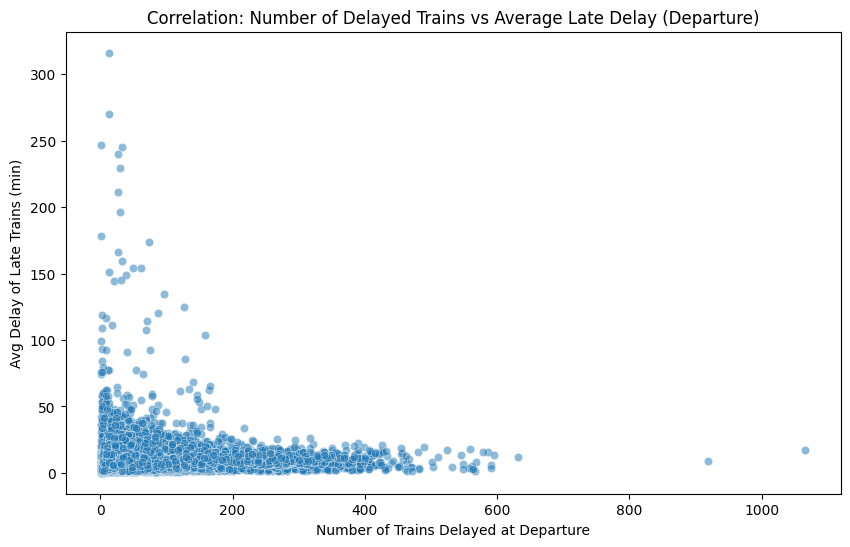

Missing values check:
Number of trains delayed at departure        246
Average delay of late trains at departure    287
Average delay of all trains at departure     227
dtype: int64


In [3594]:
# Clean numeric
df = clean_numeric_column(df, 'Number of trains delayed at departure', to_type='int')
df = clean_numeric_column(df, 'Average delay of late trains at departure', text_to_remove='min', to_type='float')
df = clean_numeric_column(df, 'Average delay of all trains at departure', text_to_remove='min', to_type='float')

# Round floats to 2 decimal places for clarity
df['Average delay of late trains at departure'] = df['Average delay of late trains at departure'].round(2)
df['Average delay of all trains at departure'] = df['Average delay of all trains at departure'].round(2)

# Validation 1: Delayed trains > Scheduled trains
incoherent_rows = df['Number of trains delayed at departure'] > df['Number of scheduled trains']
if incoherent_rows.any():
    print(f"WARNING: {incoherent_rows.sum()} rows found where delayed trains exceed scheduled trains. Setting to NULL.")
    df.loc[incoherent_rows, 'Number of trains delayed at departure'] = pd.NA

# Validation 2: If no trains delayed, average late delay must be NaN
zero_delayed_rows = (df['Number of trains delayed at departure'] == 0)
df.loc[zero_delayed_rows, 'Average delay of late trains at departure'] = np.nan

# Visualize correlation between number of delayed trains and average delay
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Number of trains delayed at departure', y='Average delay of late trains at departure', alpha=0.5)
plt.title('Correlation: Number of Delayed Trains vs Average Late Delay (Departure)')
plt.xlabel('Number of Trains Delayed at Departure')
plt.ylabel('Avg Delay of Late Trains (min)')
plt.show()

print("Missing values check:")
print(df[['Number of trains delayed at departure', 'Average delay of late trains at departure', 'Average delay of all trains at departure']].isna().sum())

### Arrival Delays
We clean the columns related to delays at the arrival station. Similar to departure delays, we apply validation rules:
1. Number of delayed trains cannot exceed scheduled trains.
2. If zero trains were delayed, the average delay of late trains must be zero.

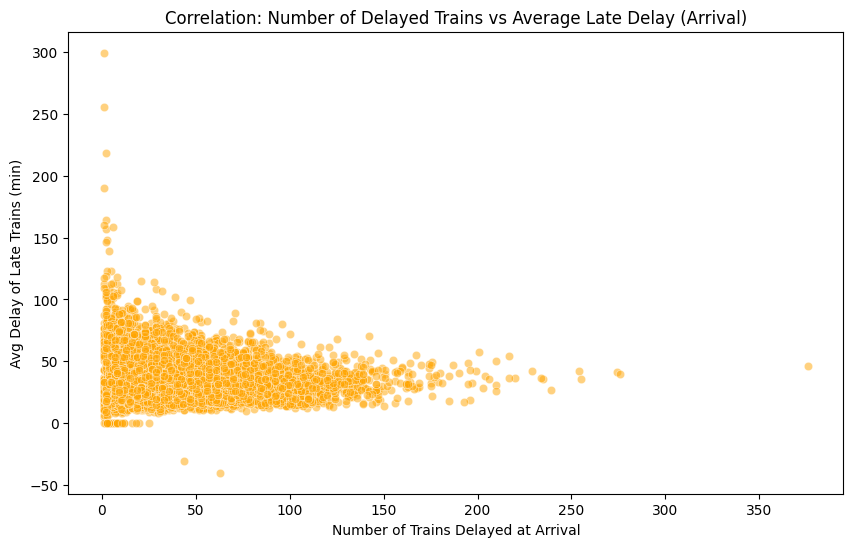

Missing values check (Arrival):
Number of trains delayed at arrival        226
Average delay of late trains at arrival    341
Average delay of all trains at arrival     227
dtype: int64


In [3595]:
# Clean numeric
df = clean_numeric_column(df, 'Number of trains delayed at arrival', to_type='int')
df = clean_numeric_column(df, 'Average delay of late trains at arrival', text_to_remove='min', to_type='float')
df = clean_numeric_column(df, 'Average delay of all trains at arrival', text_to_remove='min', to_type='float')

# Round floats to 2 decimal places
df['Average delay of late trains at arrival'] = df['Average delay of late trains at arrival'].round(2)
df['Average delay of all trains at arrival'] = df['Average delay of all trains at arrival'].round(2)

# Validation 1: Delayed trains > Scheduled trains
incoherent_rows = df['Number of trains delayed at arrival'] > df['Number of scheduled trains']
if incoherent_rows.any():
    print(f"WARNING: {incoherent_rows.sum()} rows found where delayed arrival trains exceed scheduled. Setting to NULL.")
    df.loc[incoherent_rows, 'Number of trains delayed at arrival'] = pd.NA

# Validation 2: If no trains delayed at arrival, average late delay must be NaN
zero_delayed_rows = (df['Number of trains delayed at arrival'] == 0)
df.loc[zero_delayed_rows, 'Average delay of late trains at arrival'] = np.nan

# Visualize correlation between number of delayed trains and average delay at arrival
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Number of trains delayed at arrival', y='Average delay of late trains at arrival', alpha=0.5, color='orange')
plt.title('Correlation: Number of Delayed Trains vs Average Late Delay (Arrival)')
plt.xlabel('Number of Trains Delayed at Arrival')
plt.ylabel('Avg Delay of Late Trains (min)')
plt.show()

print("Missing values check (Arrival):")
print(df[['Number of trains delayed at arrival', 'Average delay of late trains at arrival', 'Average delay of all trains at arrival']].isna().sum())

### Delay and Severity
We clean the columns that categorize delays (>15min, >30min, >60min). 
We also include the average delay for routes competing with flights.

**Validation Rules:**
A logical 'cascade' must be maintained: Total Delayed Arrival >= Delayed > 15min >= Delayed > 30min >= Delayed > 60min.

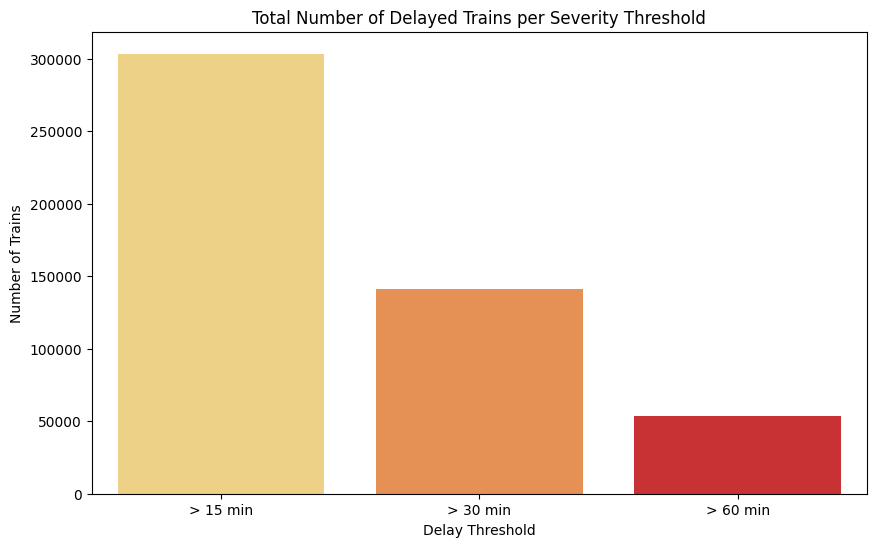

Missing values summary for delay thresholds:
Number of trains delayed > 15min                               261
Number of trains delayed > 30min                               232
Number of trains delayed > 60min                               569
Average delay of trains > 15min (if competing with flights)    225
dtype: int64


In [3596]:
# Clean categorized delay counts as Integers
df = clean_numeric_column(df, 'Number of trains delayed > 15min', to_type='int')
df = clean_numeric_column(df, 'Number of trains delayed > 30min', to_type='int')
df = clean_numeric_column(df, 'Number of trains delayed > 60min', to_type='int')

# Clean flight competition average as Float
df = clean_numeric_column(df, 'Average delay of trains > 15min (if competing with flights)', text_to_remove='min', to_type='float')
df['Average delay of trains > 15min (if competing with flights)'] = df['Average delay of trains > 15min (if competing with flights)'].round(2)

# Validation: Cascade Logic (>15 >= >30 >= >60)
incoherent_rows_15_30 = df['Number of trains delayed > 15min'] < df['Number of trains delayed > 30min']
incoherent_rows_30_60 = df['Number of trains delayed > 30min'] < df['Number of trains delayed > 60min']
incoherent_rows_total_15 = df['Number of trains delayed at arrival'] < df['Number of trains delayed > 15min']

if incoherent_rows_15_30.any() or incoherent_rows_30_60.any() or incoherent_rows_total_15.any():
    total_errors = (incoherent_rows_15_30 | incoherent_rows_30_60 | incoherent_rows_total_15).sum()
    print(f"WARNING: {total_errors} rows found with inconsistent delay cascades. Setting invalid counts to NULL.")
    # Set inconsistent values to NULL
    df.loc[incoherent_rows_15_30, 'Number of trains delayed > 30min'] = pd.NA
    df.loc[incoherent_rows_30_60, 'Number of trains delayed > 60min'] = pd.NA
    df.loc[incoherent_rows_total_15, 'Number of trains delayed > 15min'] = pd.NA

# Visualize delay severity levels
delay_sums = df[['Number of trains delayed > 15min', 'Number of trains delayed > 30min', 'Number of trains delayed > 60min']].sum()
plt.figure(figsize=(10, 6))
sns.barplot(x=delay_sums.index, y=delay_sums.values, hue=delay_sums.index, palette='YlOrRd', legend=False)
plt.title('Total Number of Delayed Trains per Severity Threshold')
plt.xlabel('Delay Threshold')
plt.ylabel('Number of Trains')
plt.xticks(ticks=[0, 1, 2], labels=['> 15 min', '> 30 min', '> 60 min'])
plt.show()

print("Missing values summary for delay thresholds:")
print(df[['Number of trains delayed > 15min', 'Number of trains delayed > 30min', 'Number of trains delayed > 60min', 'Average delay of trains > 15min (if competing with flights)']].isna().sum())

### Percentage Delay by Cause
We clean the columns representing the percentage of delays attributed to different causes (External, Infrastructure, etc.).

**Smart Strategy:**
1. If multiple values are missing in a row, we leave them as `NaN` (unrecoverable).
2. If only one value is missing, we calculate it such that the total sum equals 100%.
3. If the sum of existing values is already 100%, any missing value is set to 0.0.

In [3597]:
# List of columns representing percentages of delay causes
percentage_cols = [
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling'
]
# Clean numeric format for all percentage columns
for col in percentage_cols:
    df = clean_numeric_column(df, col, text_to_remove='%', to_type='float')
    df[col] = df[col].round(2)
# Smart Recalculation: Identify rows with exactly one missing percentage value
null_counts = df[percentage_cols].isnull().sum(axis=1)
recalculable_rows = (null_counts == 1)
if recalculable_rows.any():
    print(f"Recalculating missing percentage for {recalculable_rows.sum()} rows where 5/6 causes are present.")
    # Calculate the sum of the non-missing values
    current_sums = df.loc[recalculable_rows, percentage_cols].sum(axis=1)
    # For each row, find the single null column and fill it with (100 - sum)
    for idx in df[recalculable_rows].index:
        row = df.loc[idx, percentage_cols]
        missing_col = row[row.isnull()].index[0]
        # Ensure the value is not negative (possible if data is corrupted > 100%)
        calculated_val = max(0.0, 100.0 - current_sums[idx])
        df.loc[idx, missing_col] = round(calculated_val, 2)
# For rows where all values are already 100%, set any remaining NaNs to 0.0
df[percentage_cols] = df[percentage_cols].fillna(0.0)
# Final Consistency Check: Verify the total sum per row
df['Pct delay sum'] = df[percentage_cols].sum(axis=1)
incoherent_percentages = ~df['Pct delay sum'].between(99.0, 101.0)
if incoherent_percentages.any():
    print(f"WARNING: {incoherent_percentages.sum()} rows still have inconsistent percentage sums. Setting them to NULL.")
    df.loc[incoherent_percentages, percentage_cols] = pd.NA
# Drop temporary sum column
df = df.drop(columns=['Pct delay sum'])
print("Percentage columns cleaned and validated.")

Recalculating missing percentage for 1274 rows where 5/6 causes are present.
Percentage columns cleaned and validated.


## Dataset after cleaning

In [3598]:
print("Column names and new types are: ")

#We get names of columns in the Dataframe
columns = df.columns
for i in range(len(columns)):
    print(columns[i], end=" -> ")
    print(df[str(columns[i])].dtype)

nb_line, nb_col = df.shape

print(f"\nThere is {nb_col} columns and {nb_line} line in the new dataset.\n- {nb_line_start - nb_line} lines has been removed\n- {nb_col_start - nb_col} columns has been removed.\n {((nb_line_start - nb_line) / nb_line_start * 100):.2f}% of the dataset lines were removed")

display(df)

Column names and new types are: 
Year -> int64
Month -> int64
Season -> str
Service -> str
Departure station -> str
Arrival station -> str
Average journey time -> Int64
Number of scheduled trains -> Int64
Number of cancelled trains -> Int64
Number of real trains -> object
Number of trains delayed at departure -> Int64
Average delay of late trains at departure -> float64
Average delay of all trains at departure -> float64
Number of trains delayed at arrival -> Int64
Average delay of late trains at arrival -> float64
Average delay of all trains at arrival -> float64
Number of trains delayed > 15min -> Int64
Average delay of trains > 15min (if competing with flights) -> float64
Number of trains delayed > 30min -> Int64
Number of trains delayed > 60min -> Int64
Pct delay due to external causes -> float64
Pct delay due to infrastructure -> float64
Pct delay due to traffic management -> float64
Pct delay due to rolling stock -> float64
Pct delay due to station management and equipment reuse 

,Year,Month,Season,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of real trains,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,Pct delay due to passenger handling
0,2018,1,Winter,National,BORDEAUX SAINT JEAN,PARIS MONTPARNASSE,141,870,5,865,...,110,6.51,44,8,36.13,31.09,10.92,15.97,5.04,0.84
1,2018,1,Winter,National,LE MANS,PARIS MONTPARNASSE,56,406,1,405,...,32,5.36,9,4,20.00,35.00,16.67,16.67,8.33,3.33
2,2018,1,Winter,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,226,...,11,2.94,6,1,22.22,27.78,16.67,16.67,5.56,11.11
3,2018,1,Winter,National,PARIS MONTPARNASSE,NANTES,216,508,3,505,...,39,5.29,18,<NA>,33.33,22.22,16.67,20.37,5.56,1.85
4,2018,1,Winter,National,POITIERS,PARIS MONTPARNASSE,94,472,4,468,...,42,4.88,10,0,15.79,45.61,19.31,15.79,1.75,1.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12033,2018,11,Autumn,National,SAINT ETIENNE CHATEAUCREUX,PARIS LYON,168,113,1,112,...,14,5.51,5,2,21.05,36.84,5.26,21.05,10.53,5.26
12034,2021,5,Spring,National,PARIS MONTPARNASSE,NANTES,138,470,29,441,...,6,31.45,3,0,22.22,0.00,11.11,33.33,0.00,33.33
12049,2018,3,Spring,National,PERPIGNAN,PARIS LYON,305,163,1,162,...,23,8.47,14,7,57.14,14.29,14.29,14.29,0.00,0.00
12056,2019,2,Winter,National,NICE VILLE,PARIS LYON,357,159,4,155,...,33,9.32,13,5,18.18,36.36,24.24,12.12,9.09,0.00


### Cleaning efficiency visualisation
After the cleaning process we identify which cells were fixed, which were removed from the original dataset

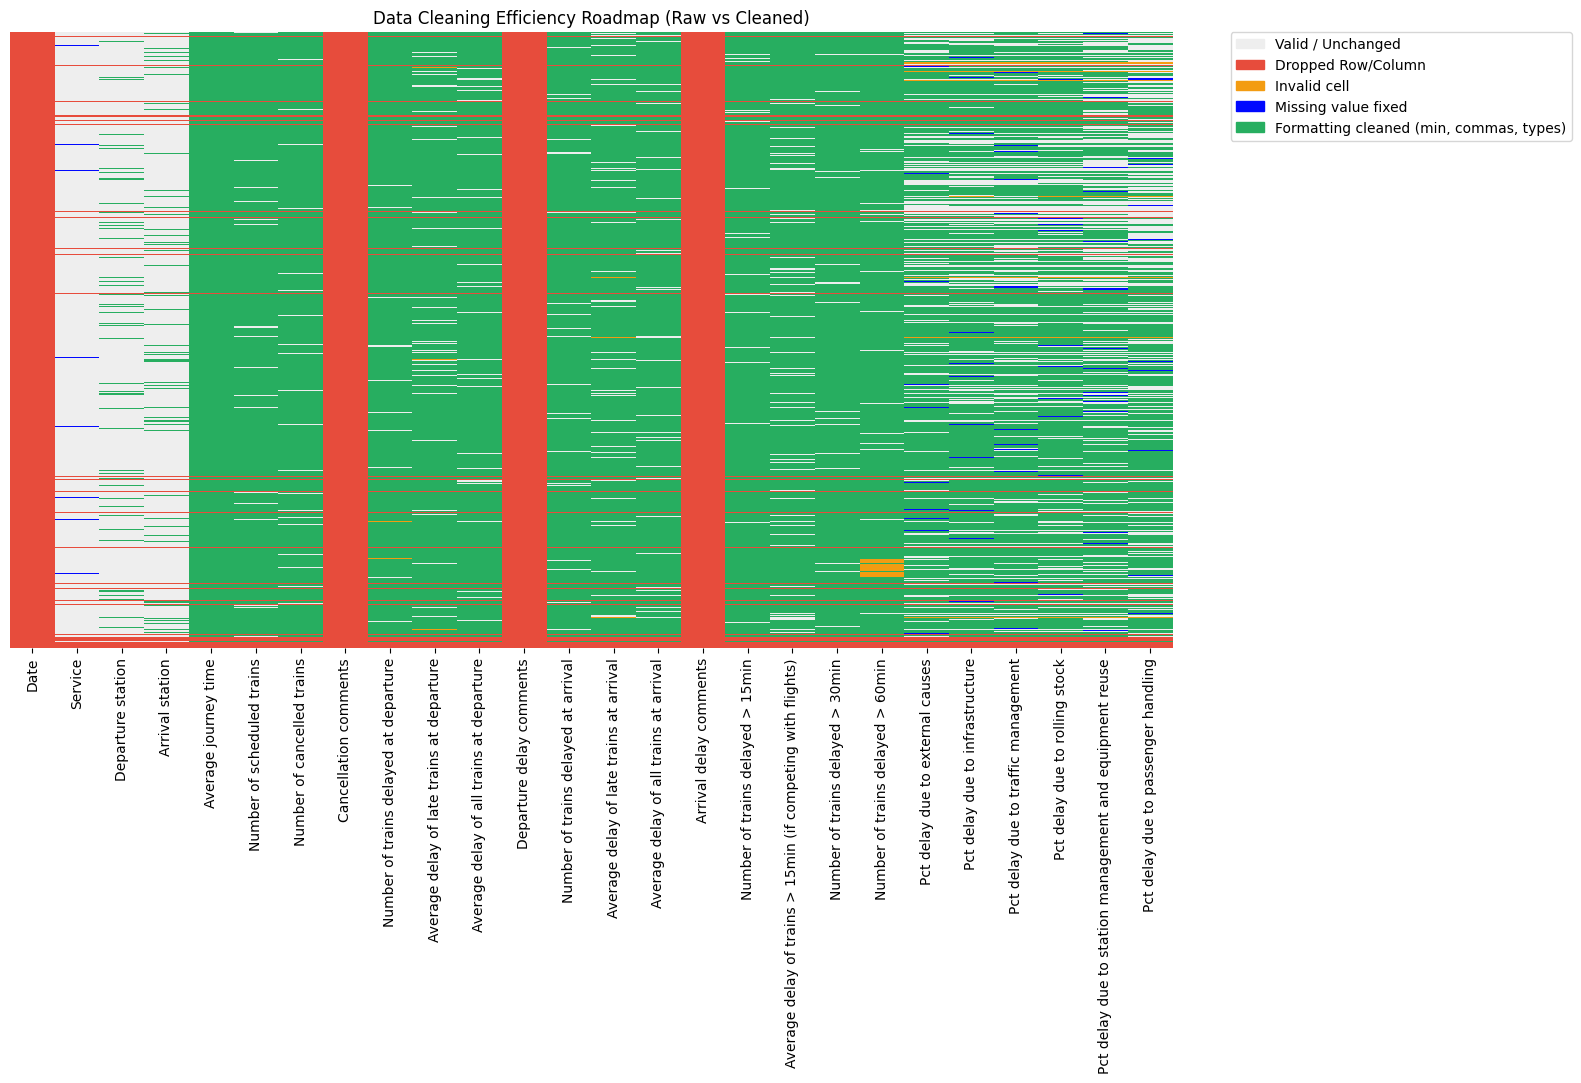

In [3599]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# 1. Prepare a status matrix based on df_raw
status_matrix = pd.DataFrame(0, index=df_raw.index, columns=df_raw.columns)

# 2. Identify Dropped Rows (Red - Code 1)
dropped_rows = df_raw.index.difference(df.index)
status_matrix.loc[dropped_rows, :] = 1

# Align cleaned data to raw data structure for comparison
df_aligned = df.reindex_like(df_raw)

for col in df_raw.columns:
    if col not in df.columns:
        status_matrix[col] = 1 # Column was dropped
        continue
        
    raw_col = df_raw[col]
    clean_col = df_aligned[col]
    
    # 3. Errors set to NULL (Orange - Code 2)
    # Was not null in raw, but is null in cleaned (excluding dropped rows (Red))
    nullified = raw_col.notnull() & clean_col.isnull()
    status_matrix.loc[nullified & ~status_matrix.index.isin(dropped_rows), col] = 2
    
    # 4. Missing values fixed (Blue - Code 3)
    # Was null in raw, now has a value
    fixed = raw_col.isnull() & clean_col.notnull()
    status_matrix.loc[fixed, col] = 3
    
    # 5. Values cleaned/formatted (Green - Code 4)
    # Difference in values that are NOT null in both
    # We use string comparison to detect formatting changes (commas, 'min', etc.)
    cleaned = (raw_col.astype(str).str.strip() != clean_col.astype(str).str.strip()) & \
              raw_col.notnull() & clean_col.notnull()
    status_matrix.loc[cleaned & ~status_matrix.index.isin(dropped_rows), col] = 4

# --- Visualisation ---
plt.figure(figsize=(15, 8))

# Palette: Gray (0: Unchanged), Red (1: Dropped), Orange (2: Inconsistency), Blue (3: Fixed), Green (4: Cleaned)
colors = ['#EEEEEE', '#e74c3c', '#f39c12', '#0008ff', '#27ae60']
custom_cmap = ListedColormap(colors)

# Create a heatmap to visualize the cleaning status of each cell
sns.heatmap(status_matrix, cbar=False, yticklabels=False, cmap=custom_cmap)
plt.title('Data Cleaning Efficiency Roadmap (Raw vs Cleaned)')

# Custom Legend
legend_labels = {
    'Valid / Unchanged': '#EEEEEE',
    'Dropped Row/Column': '#e74c3c',
    'Invalid cell': '#f39c12',
    'Missing value fixed': '#0008ff',
    'Formatting cleaned (min, commas, types)': '#27ae60'
}
# Create custom legend patches
patches = [mpatches.Patch(color=color, label=label) for label, color in legend_labels.items()]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

# Bilan of the first step

In this initial phase, we successfully transformed the raw dataset into a robust foundation for analysis:
- **Structural Cleaning:** Removed duplicate rows and text comments.
- **Feature Engineering:** Extracted temporal features (`Year`, `Month`, `Season`) and standardized categorical data (`Service`, `Stations`).
- **Smart Fixing:** Implemented fixing strategies, such as deducing missing `Service` types from a catalog of known journeys and recalculating missing delay percentages to ensure a 100% total.
- **Logic Validation:** Used strict rules to ensure data coherence (cancelled trains ≤ scheduled trains, consistent cascade for delay severities >15 ≥ >30 ≥ >60).
- **Data Formatting:** Cleaned numerical columns by stripping unwanted text like 'min' and '%' before converting them to their appropriate numeric types.

The dataset is now clean, consistent, and fully prepared for the Data Visualization and Analysis phase.

# Step 2 - Data Visualisation and Analysis

Now that we have cleaned the dataset, we can use them to understand the dataset better. It will be useful to improve the predictive model accuracy.

In [3600]:
#We get the dataset cleaned from the file
new = df.copy()

## Observations on datas

Here we observe the dataset with graphics to understand it better.

### Relation between cancelled trains in function of departure station

We observe the percentage of cancelled trains in function of departure station

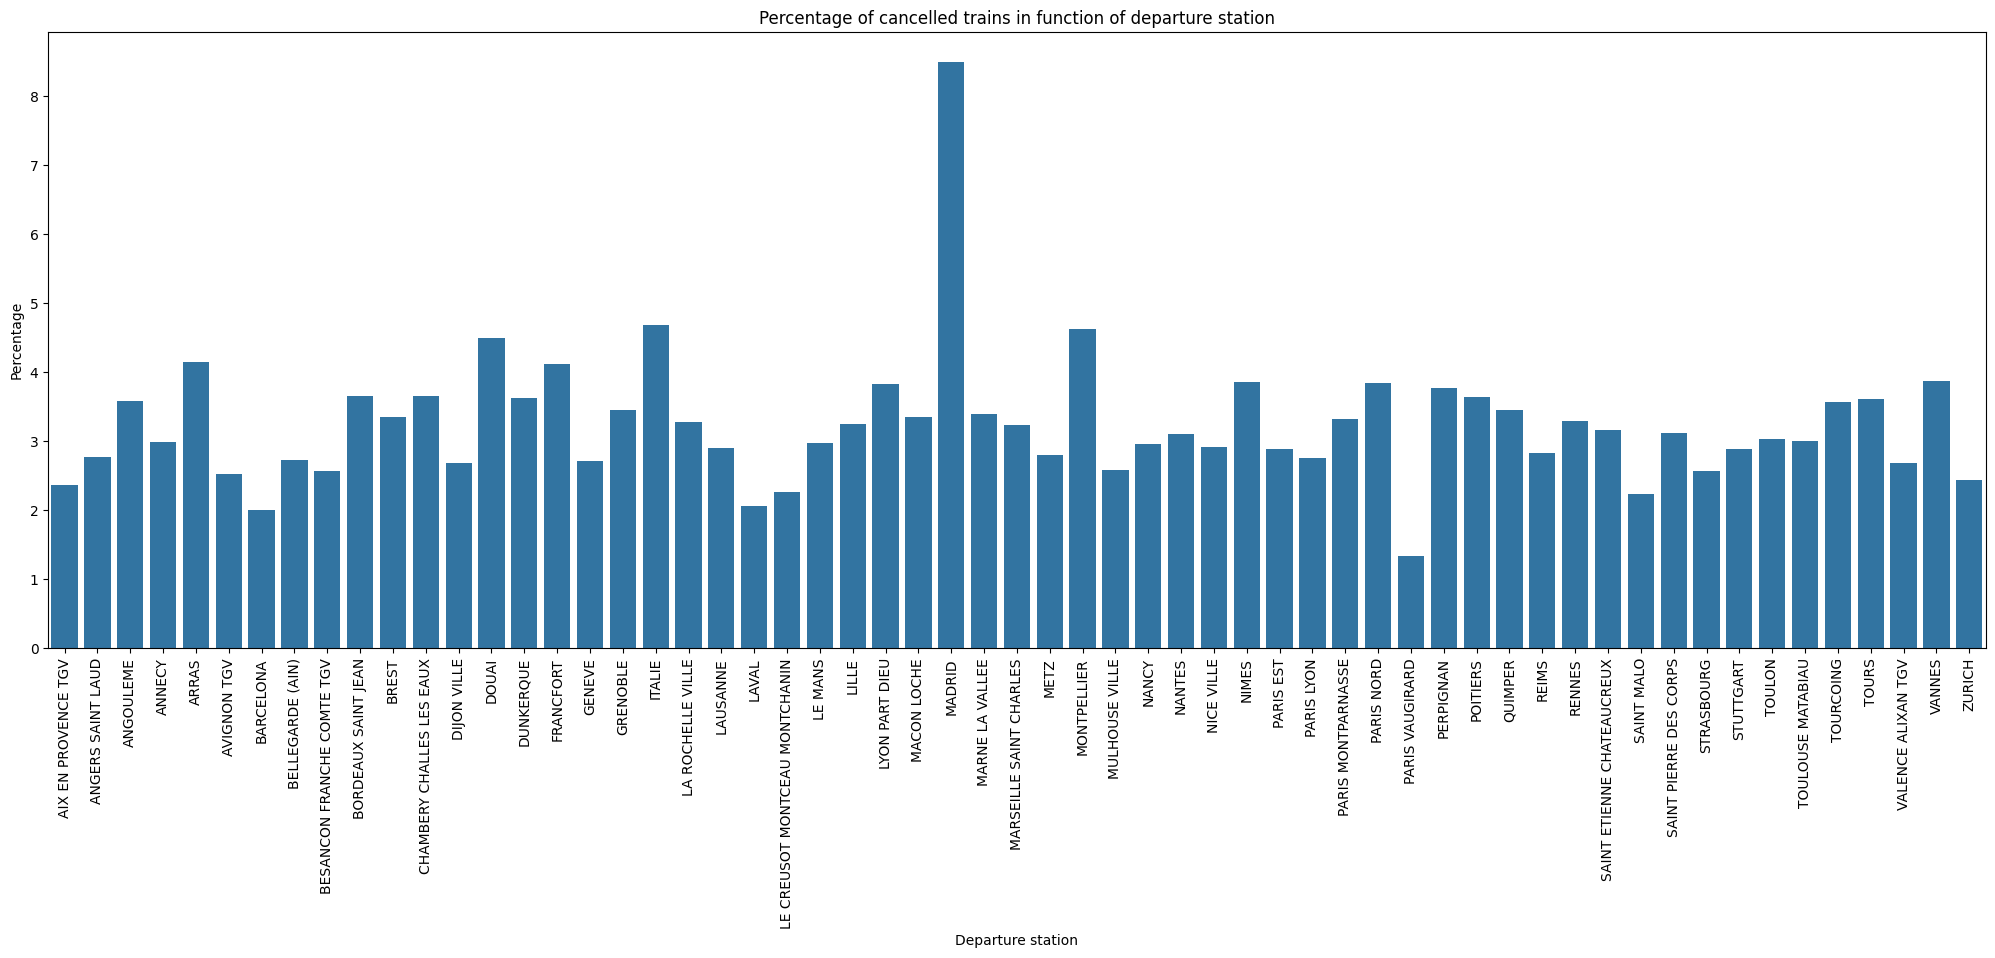

In [3601]:
#Decide size of graphic
plt.figure(figsize=(25,8))

#Exclude all columns with 0 in name of departure
temp = new[new["Departure station"] != "0"]

#Group rows by departure stations and choose to sum datas of numeric columns
temp = temp.groupby("Departure station").aggregate("sum")

#New column with correlation between cancelled trains and scheduled ones
temp['Correlation cancelled / schedule'] = 100 * temp['Number of cancelled trains'] / temp['Number of scheduled trains']

#Taking datas from dataset and precise columns that are put in relation
sns.barplot(data=temp, x='Departure station', y='Correlation cancelled / schedule')
plt.title('Percentage of cancelled trains in function of departure station')
plt.xticks(rotation=90)
plt.ylabel('Percentage')
plt.show()

Here, we can observe that the city with the most proportion of cancelled train over total scheduled train is Madrid with 8 trains cancelled for 100 scheduled. And the station with less cancelled train for number of schedule trains is Paris Vaugirard with 1 for 100. But for other cities, it's pretty the same everywhere.

### Relation between late at departure in function of the season

We'll observe in function of season, the number of lates per station at departure.

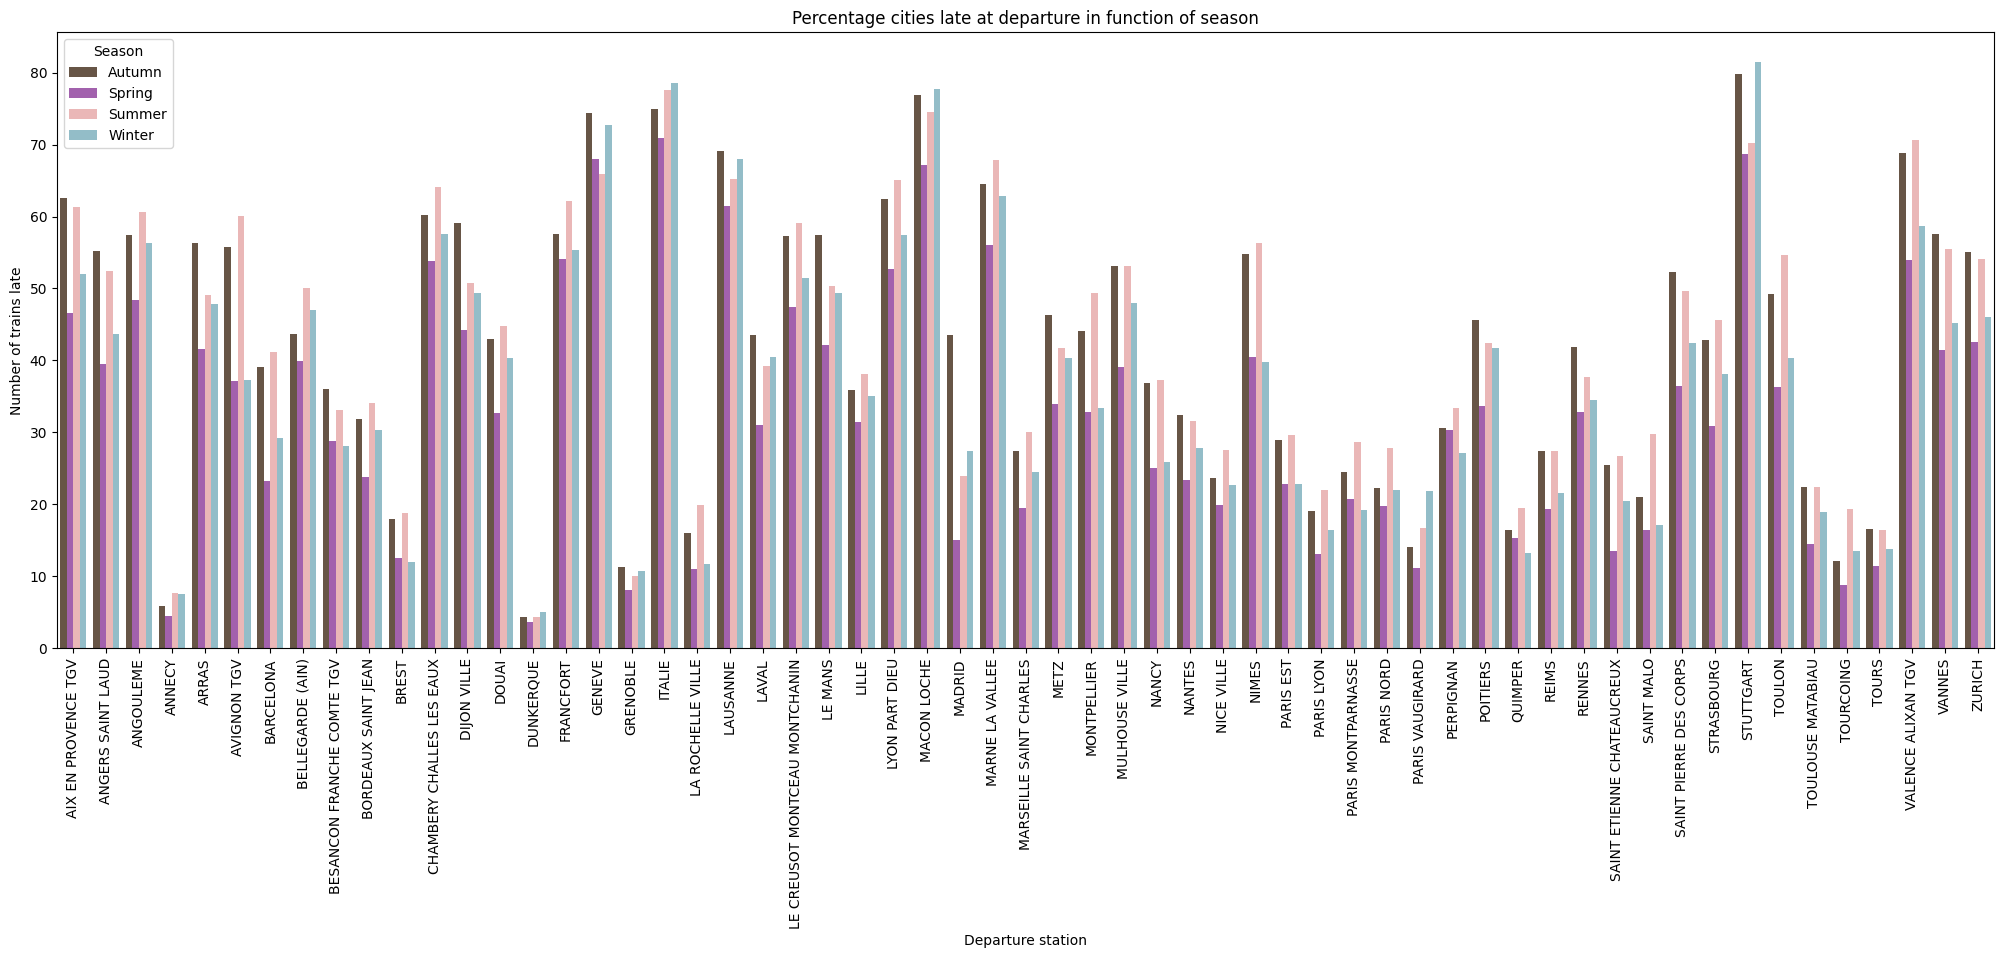

In [3602]:
#Decide which season has which color
palette = {"Winter": "#8AC2D1", "Summer": "#F3AEAE", "Autumn": "#6D5540", "Spring": "#AB54BA"}

#Decide size of graphic
plt.figure(figsize=(25,8))

#Get seasons and departure stations and choose to sum datas of numeric columns
seasons = new.drop(columns=["Arrival station", "Service"])
seasons["PCT delayed at departure"] = 100 * seasons["Number of trains delayed at departure"] / seasons["Number of scheduled trains"]
seasons = seasons.groupby(["Departure station", "Season"]).aggregate("mean").reset_index()

#Taking datas from dataset and precise columns that are put in relation
sns.barplot(data=seasons, x='Departure station', y='PCT delayed at departure', hue='Season', palette=palette)
plt.title('Percentage cities late at departure in function of season')
plt.xticks(rotation=90)
plt.ylabel('Number of trains late')
plt.show()

**Conclusion**

We can observe that:
- Up to 80% of trains are delayed at certain stations, depending on the city. At a minimum, 5% of trains depart late.
- The season with the most late at departure is Summer and the less is Spring
- There's a lot of variations on the percentage of trains late, in function of the city of departure, so **the city of departure is an important data**.
- Even if the city of departure influence a lot the delay at departure, the gap between the different seasons isn't meaningful.

### Relation between late at departure in function of the season

We'll observe in function of season, the number of lates per station at arrival.

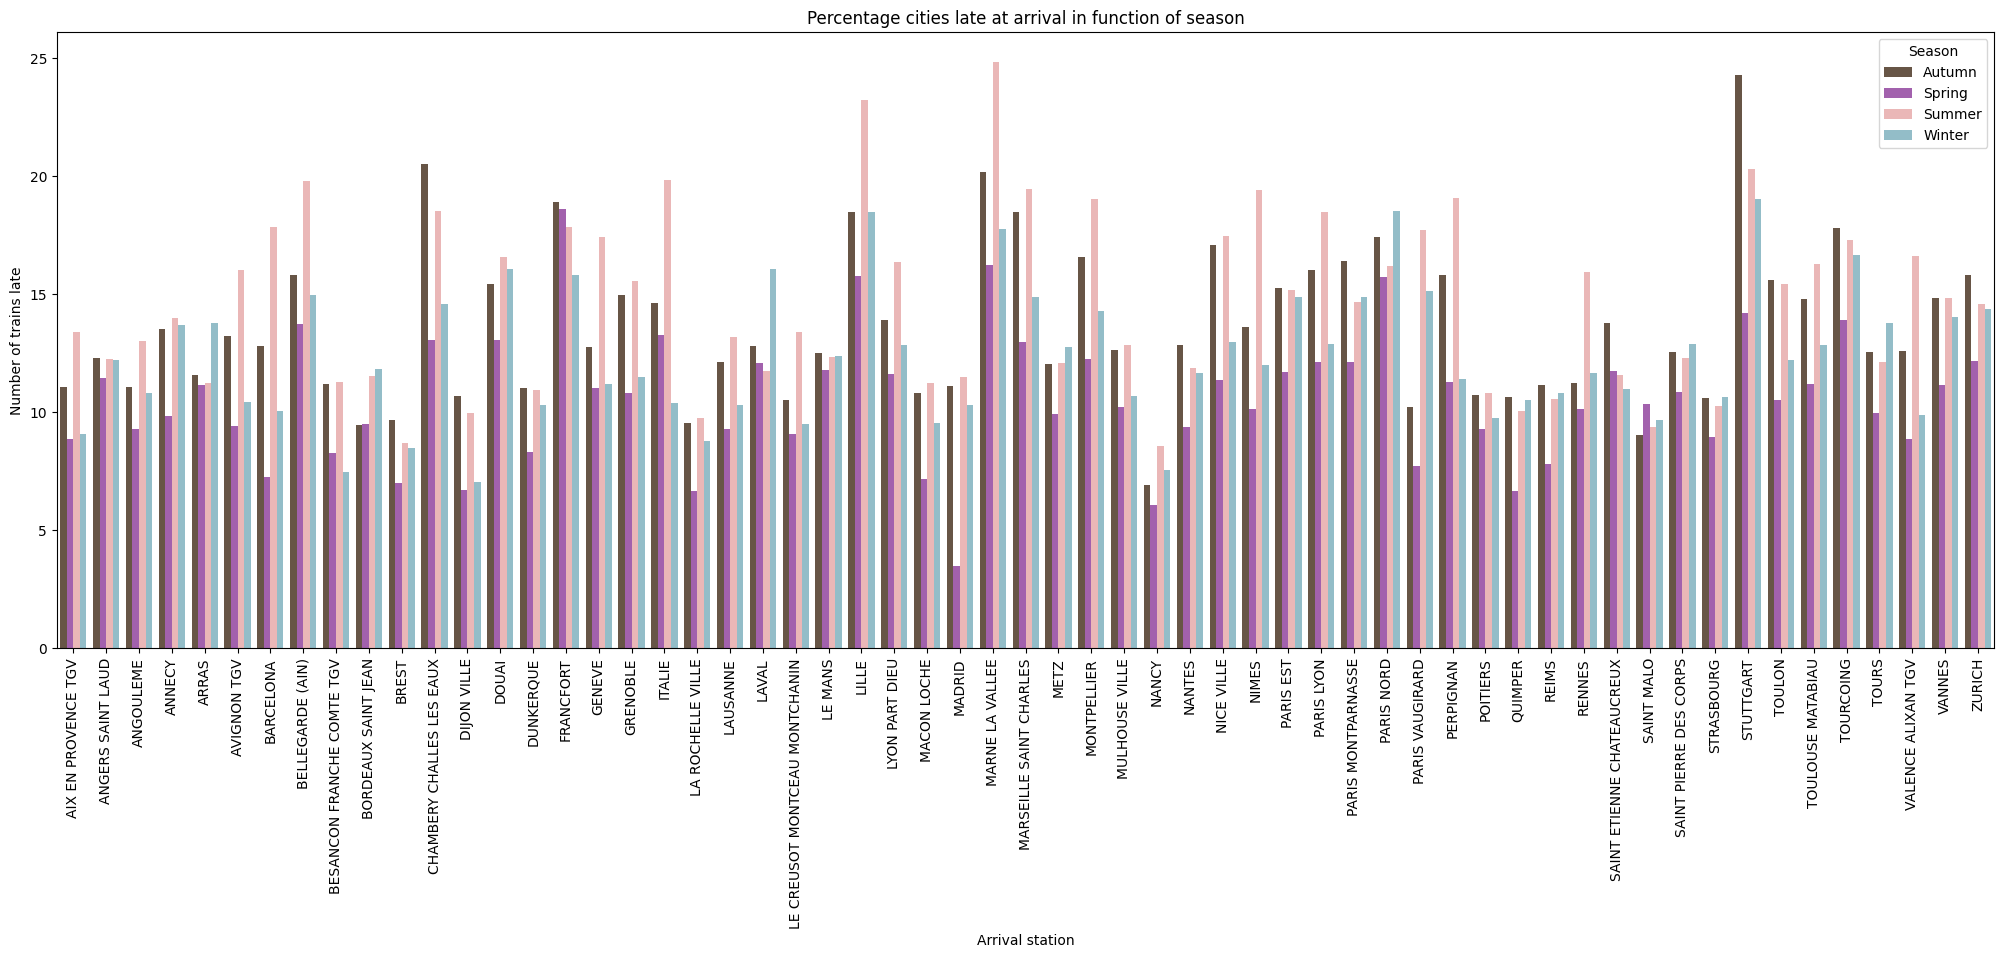

In [3603]:
#Decide size of graphic
plt.figure(figsize=(25,8))

#Get seasons and arrival stations and choose to sum datas of numeric columns
seasons = new.drop(columns=["Departure station", "Service"])
seasons["PCT delayed at arrival"] = 100 * seasons["Number of trains delayed at arrival"] / seasons["Number of scheduled trains"]
seasons = seasons.groupby(["Arrival station", "Season"]).aggregate("mean").reset_index()

#Taking datas from dataset and precise columns that are put in relation
sns.barplot(data=seasons, x='Arrival station', y='PCT delayed at arrival', hue='Season', palette=palette)
plt.title('Percentage cities late at arrival in function of season')
plt.xticks(rotation=90)
plt.ylabel('Number of trains late')
plt.show()

**Conclusion**

We can observe that:
- Up to 25% of trains are delayed at certain stations, depending on the city. At a minimum, 3% of trains depart late.
- The season with the most late at arrival is Summer and the less is Spring.
- There's not a lot of variations on the percentage of trains late, in function of the city of arrival.
- Even if the city of arrival influence a lot the delay at arrival, the gap between the different seasons isn't meaningful.

### Lates per year
We now will observe the curve of evolution of lates during years.

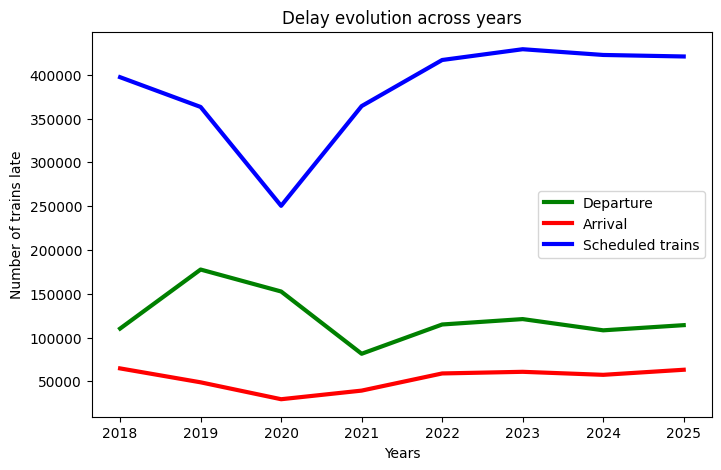

In [3604]:
#Decide size of graphic
plt.figure(figsize=(8,5))

#Group dataset by factor year and sum other columns
years = new.groupby("Year").aggregate("sum")

#Print both numbers of late arrival and late departure, across all stations
sns.lineplot(data=years, x='Year', y='Number of trains delayed at departure', label="Departure", color='green', linewidth=3)
sns.lineplot(data=years, x='Year', y='Number of trains delayed at arrival', label="Arrival", color='red', linewidth=3)
sns.lineplot(data=years, x='Year', y='Number of scheduled trains', label="Scheduled trains", color='blue', linewidth=3)
plt.title('Delay evolution across years')
plt.xlabel('Years')
plt.ylabel('Number of trains late')
plt.show()

**Conclusion**

We can observe that :
- There's more trains delayed at departure than at arrival.
- The number of trains decreased from 2018 to 2020, then started to increase before stabilizing around 2022.
- The peak of trains delayed at departure is in 2019 with 180 000 trains late this year.
- The peak of trains delayed at arrival is in 2018 with 68 000 trains late this year.
- The curve is fairly consistent for trains arriving late, despite a decrease in 2020, which is logical with the decrease of number of trains.
- There was a sudden increase in the number of delayed trains departing between 2018 and 2019, then a decrease until 2021, after which it stabilized.

### Lates per year per city at departure

We'll observe the evolution of delays at departure over years for top 10 cities with most delays.

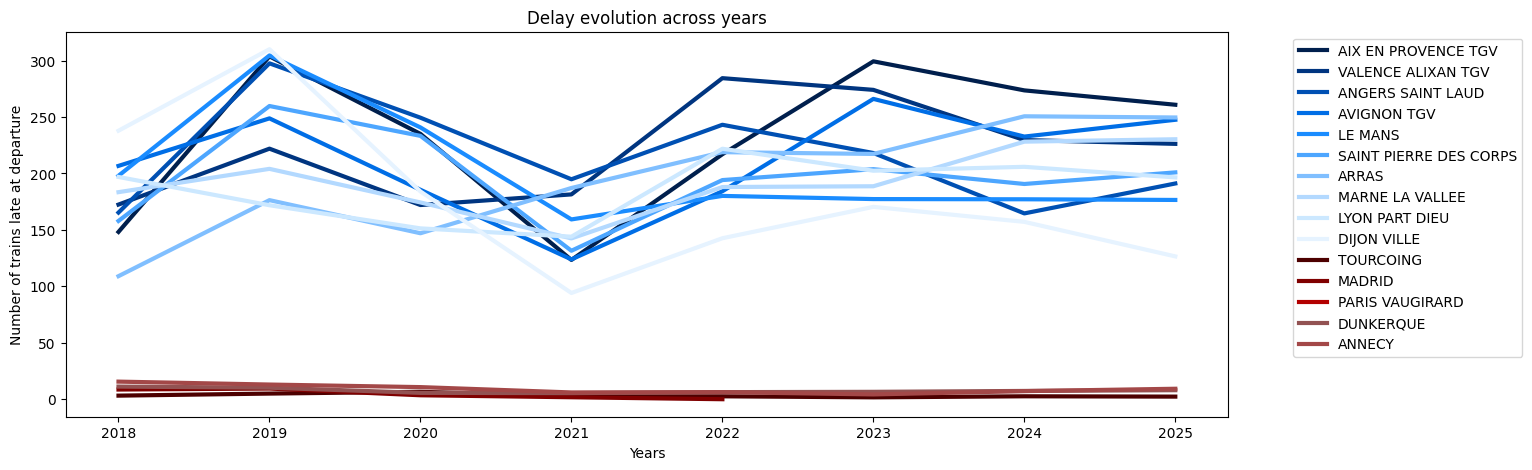

In [3605]:
#Colors for two types of stations observed
blues = ['#001f4d', '#003580', '#0050b3', '#006ee6', '#1a8cff', '#4da6ff', '#80bfff', '#b3d9ff', '#cce8ff', '#e6f3ff']
reds = ['#4d0000', '#800000', '#b30000', "#925252", "#a34848", '#ff4d4d', '#ff8080', '#ffb3b3', '#ffcccc', '#ffe6e6']

def lates_per_city_per_year(top_stations, colors, station_obs, nb_of_trains, remove_station):
    """
    Draw correlation between top (or bottom) stations and the number of trains delayed
    """
    #Get lines for departure stations that are in top_stations and remove columns that may cause problems for means
    stations = new[new[station_obs].isin(top_stations)]
    stations.drop(columns=[remove_station, "Service", "Season"], inplace=True)
    i = 0
    for elt in top_stations:
        #Taking city that corresponds to the elt in top_stations and mean all of datas, grouping per year
        city = stations[stations[station_obs] == elt]
        city.drop(columns=[station_obs], inplace=True)
        city = city.groupby("Year").aggregate("mean")
        sns.lineplot(data=city, x='Year', y=nb_of_trains, label=elt, linewidth=3, color=colors[i])
        i += 1

#Decide size of graphic
plt.figure(figsize=(15,5))

#Get name of top 10 stations with the most delays at departure, and store them in top_stations
top_stations = new.groupby("Departure station")
top_stations = top_stations["Number of trains delayed at departure"].mean().nlargest(10).index

#Get name of top 10 stations with the most delays at departure, and store them in top_stations
less_stations = new.groupby("Departure station")
less_stations = less_stations["Number of trains delayed at departure"].mean().nsmallest(5).index

lates_per_city_per_year(top_stations, blues, "Departure station", "Number of trains delayed at departure", "Arrival station")
lates_per_city_per_year(less_stations, reds, "Departure station", "Number of trains delayed at departure", "Arrival station")

plt.title('Delay evolution across years')
plt.xlabel('Years')
plt.ylabel('Number of trains late at departure')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Conclusion**

We can observe that:
- Before 2021, these cities vary a lot, then they become constant.
- The year when minimum of numbers of trains late at departure is 2020.
- Madrid don't have any datas after 2022, so it's better for the model to remove this station.

In [3606]:
new.drop(new[new["Departure station"] == "Madrid"].index, inplace=True)

### Lates per year per city at arrival

We'll observe the evolution of delays at arrival over years for top 10 cities with most delays.

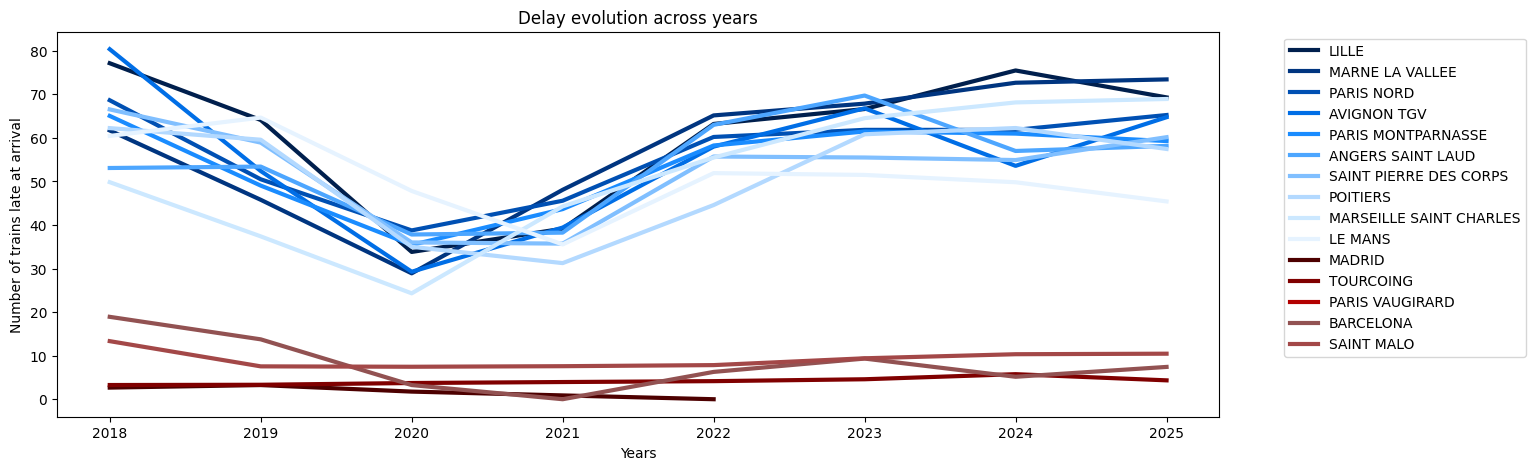

In [3607]:
#Decide size of graphic
plt.figure(figsize=(15,5))

#Get name of top 10 stations with the most delays at arrival, and store them in top_stations
top_stations = new.groupby("Arrival station")
top_stations = top_stations["Number of trains delayed at arrival"].mean().nlargest(10).index

#Taking also bottom 10 to check extreme values
less_stations = new.groupby("Arrival station")
less_stations = less_stations["Number of trains delayed at arrival"].mean().nsmallest(5).index

lates_per_city_per_year(top_stations, blues, "Arrival station", "Number of trains delayed at arrival", "Departure station")
lates_per_city_per_year(less_stations, reds, "Arrival station", "Number of trains delayed at arrival", "Departure station")

plt.title('Delay evolution across years')
plt.xlabel('Years')
plt.ylabel('Number of trains late at arrival')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Conclusion**

We can observe that:
- Before 2022, the cities decrease between 2018 and 2020, then an increase.
- The number of trains late at arrival is pretty constant after 2022.
- Madrid don't have any datas after 2022, so it's better for the model to remove this station.

In [3608]:
new.drop(new[new["Arrival station"] == "Madrid"].index, inplace=True)

### Number of trains scheduled and late trains

We'll observe the number of lates trains in function of number of real trains.

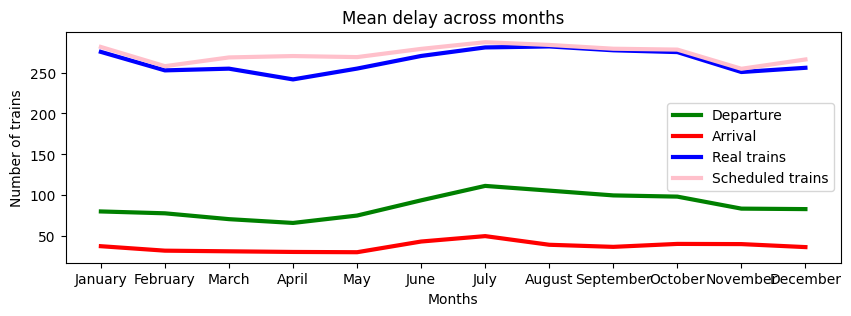

In [3609]:
#Decide size of graphic
plt.figure(figsize=(10,3))

#Group dataset by factor year and mean other columns (drop columns with str values)
months = new.drop(columns=["Departure station", "Arrival station", "Season", "Service"])
months = months.groupby("Month").aggregate("mean").reset_index()

#Replace months numbers by their name
month_list = {1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"}
months["Month"] = months["Month"].map(month_list)

#Print both numbers of late arrival and late departure, across all stations
sns.lineplot(data=months, x='Month', y='Number of trains delayed at departure', label="Departure", color='green', linewidth=3)
sns.lineplot(data=months, x='Month', y='Number of trains delayed at arrival', label="Arrival", color='red', linewidth=3)
sns.lineplot(data=months, x='Month', y='Number of real trains', label="Real trains", color='blue', linewidth=3)
sns.lineplot(data=months, x='Month', y='Number of scheduled trains', label="Scheduled trains", color='pink', linewidth=3)
plt.title('Mean delay across months')
plt.xlabel('Months')
plt.ylabel('Number of trains')
plt.show()

**Conclusion**

We can observe that:
- There's more trains between May and August and less between January and April.
- The number of trains during a year doesn't vary a lot.
- There's a mean of 260 trains per year, a mean of 25 trains delayed at arrival and a mean of 80 trains delayed at departure.
- All the curves follows the scheduled trains, which is logical.
- There's not a lot of variation on the number of trains per months, so it's not an important indicator.

### Correlation between cities and average delay at departure

In what the station of departure influence the late at departure.

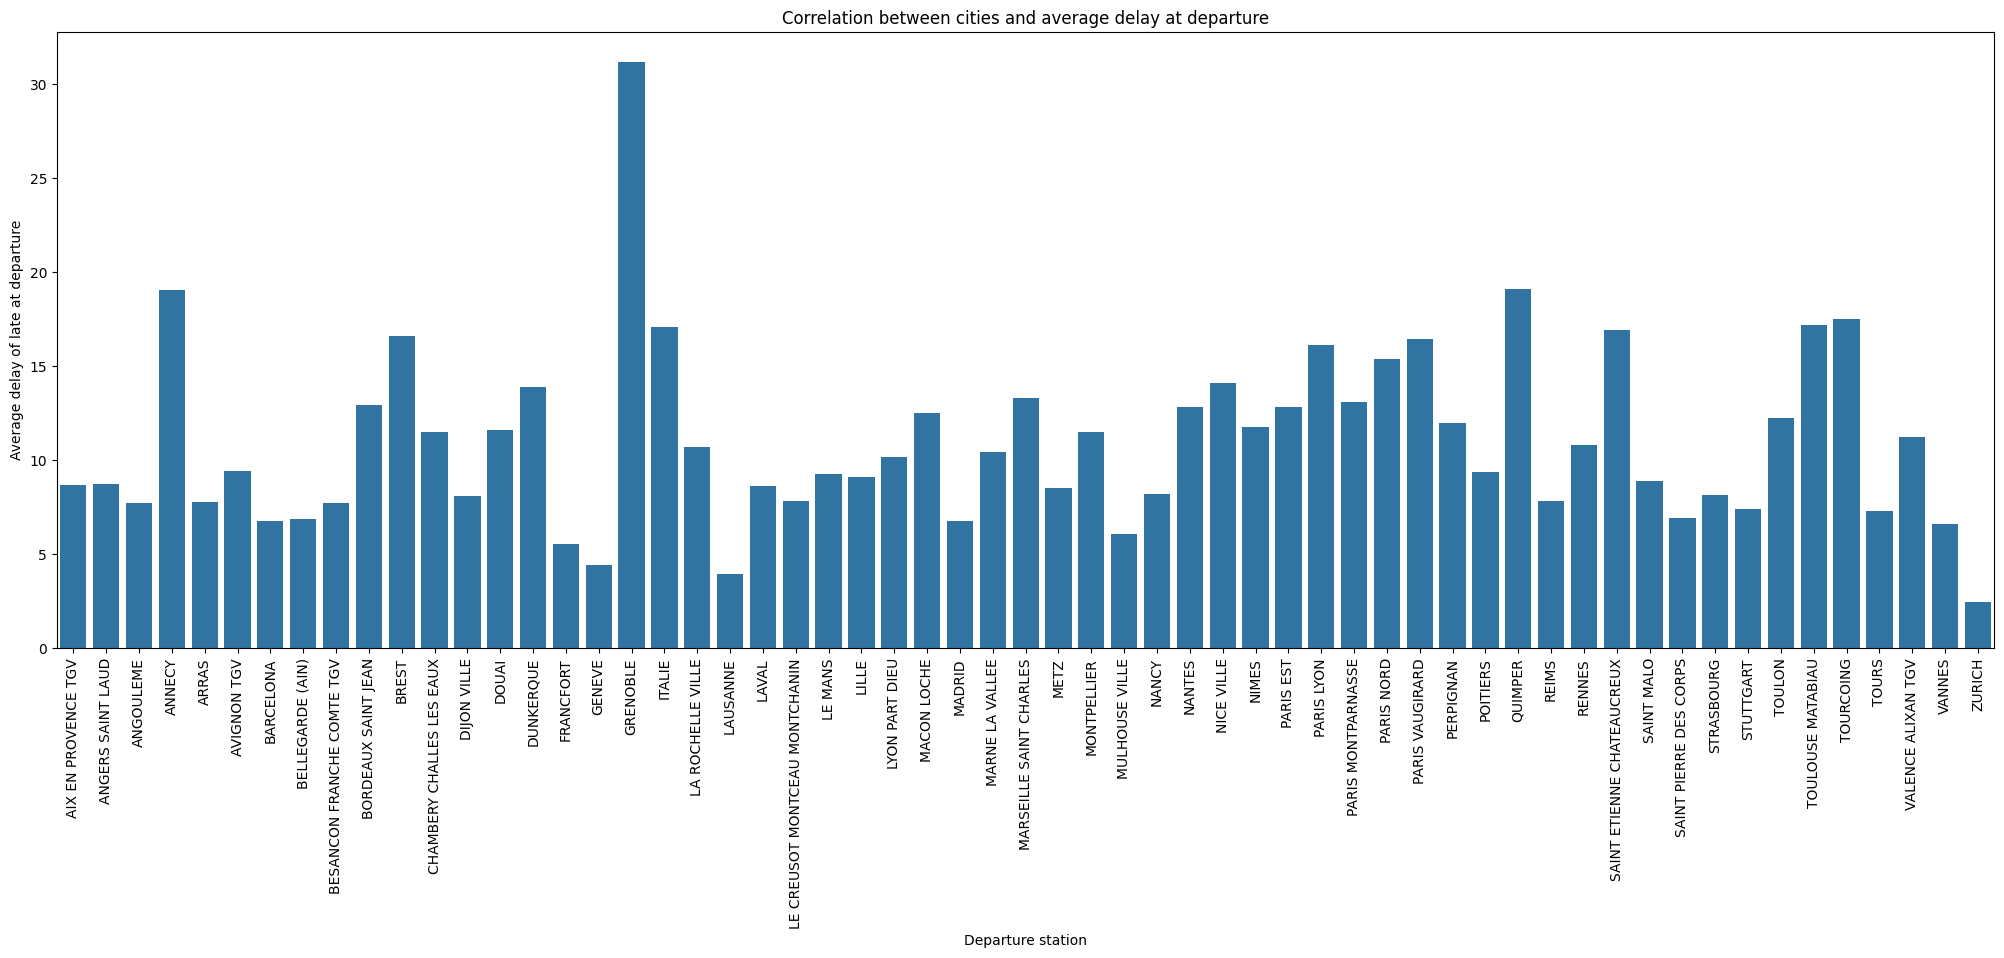

In [3610]:
#Decide size of graphic
plt.figure(figsize=(25,8))

#Group dataset by factor departure station and mean other columns (drop columns with str values)
averages = new.drop(columns=["Arrival station", "Season", "Service"])
averages = averages.groupby("Departure station").aggregate("mean").reset_index()

#Precise columns that are put in relation (Departure station is put on the x axis and avg delay of late trains at departure on y axis)
sns.barplot(data=averages, x='Departure station', y='Average delay of late trains at departure')
plt.title('Correlation between cities and average delay at departure')
plt.xticks(rotation=90)
plt.ylabel('Average delay of late at departure')
plt.show()

**Conclusion**

We can observe that:
- The departure station with the most average delay at departure is Grenoble with 30 minutes and the less is Zurich with 3 minutes.
- Average delay at departure for all departure stations is 8 minutes.
- Average delay at departure is pretty variable over the cities, so those two parameters are link.

### Correlation between cities and average delay at arrival

In what stations of departure and arrival influence the late at arrival.

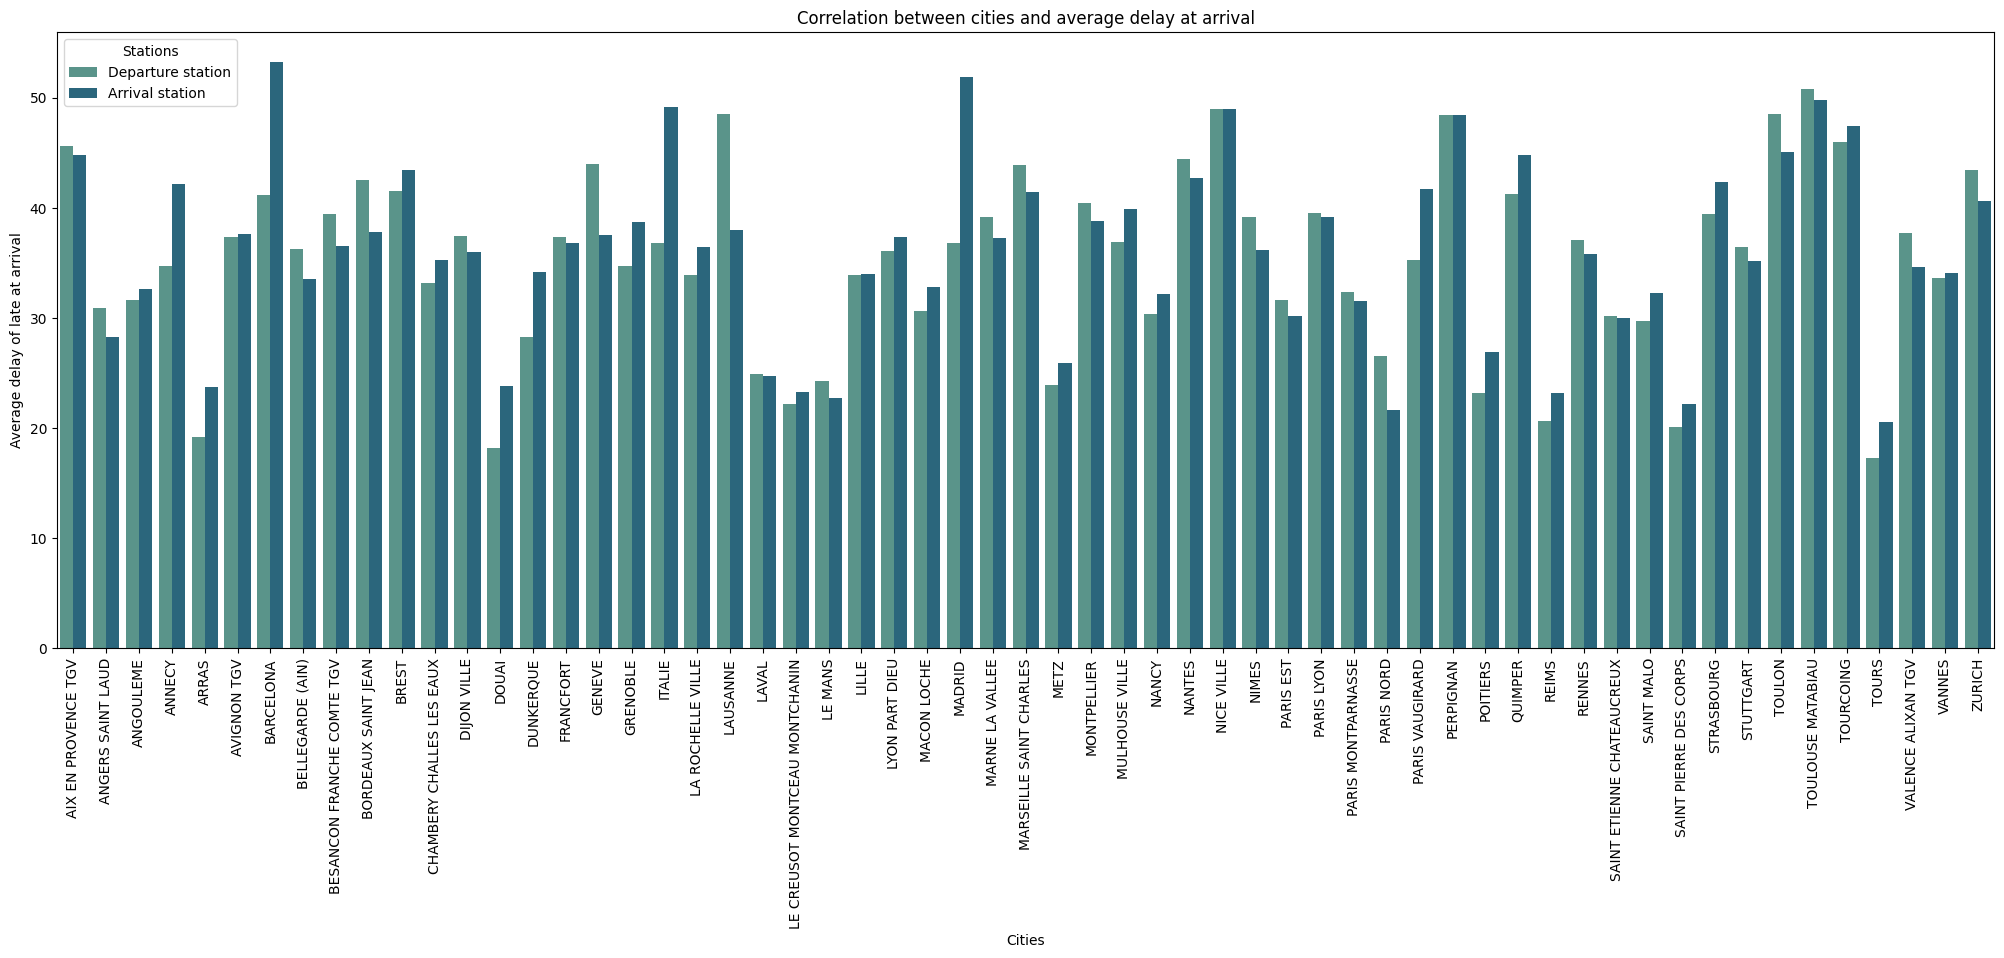

In [3611]:
#Decide size of graphic
plt.figure(figsize=(25,8))

#Group dataset by factor departure station and mean other columns (drop columns with str values)
other = new.drop(columns=["Season", "Service"])
other = other.groupby(["Departure station", "Arrival station"]).aggregate("mean").reset_index()

#Combination of Departure station and Arrival station in one column, with another that describes which one is which
other = other.melt(var_name="Stations", value_vars=["Departure station", "Arrival station"], value_name="Cities", id_vars=["Average delay of late trains at arrival"])

#Precise columns that are put in relation (Departure station is put on the x axis and avg delay of late trains at departure on y axis)
sns.barplot(data=other, x="Cities", y='Average delay of late trains at arrival', hue='Stations', palette="crest", errorbar=None)
plt.title('Correlation between cities and average delay at arrival')
plt.xticks(rotation=90)
plt.ylabel('Average delay of late at arrival')
plt.show()

**Conclusion**

We can observe that:
- The average delay of late at arrival depends on the arrival and the departure stations.
- The arrival station is more important because it's influence more the late, even if they're really closes.
- Mean of delays at arrival is 30 minutes, top is 55 minutes with Barcelona at arrival and less is 15 minutes for Tours as departure.

## Removing extreme values

This part is here to clean another time the dataset with extreme values.

In [3612]:
def remove_extremes(df, column_name):
   """
   Remove the outliers percentiles in column of dataframe
   """
   lower_q = 0.001
   upper_q = 0.999

   # We calculate the lower and upper bounds based on the specified quantiles
   lower_bound = df[column_name].quantile(lower_q)
   upper_bound = df[column_name].quantile(upper_q)

   # We filter the DataFrame to include only rows where the column values are within the bounds
   df_filtered = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
   return df_filtered

### Mean of number of scheduled trains in function of years

Does some months of certain year has weird number of scheduled trains.

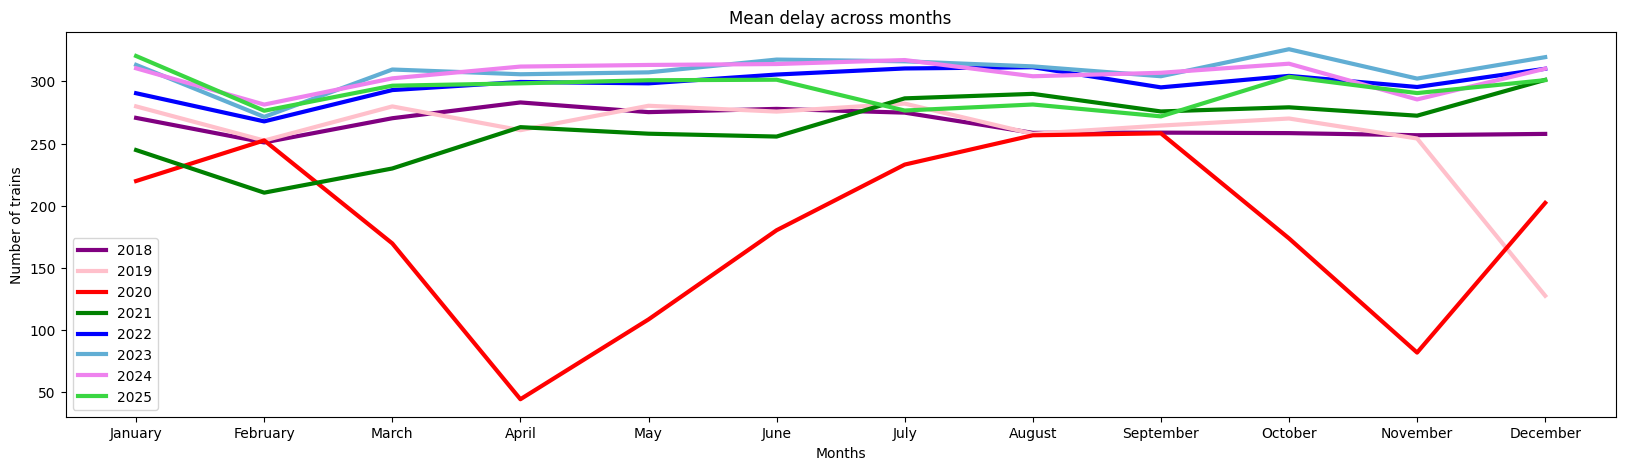

In [3613]:
#Decide size of graphic
plt.figure(figsize=(20,5))

#Palet color
colors = ['purple', 'pink', 'red', 'green', 'blue', '#61AED4', 'violet', '#3AD642']

#Group dataset by factor year and mean other columns (drop columns with str values)
months = new.drop(columns=["Departure station", "Arrival station", "Season", "Service"])
months = months.groupby(["Month", "Year"]).aggregate("mean").reset_index()

#Replace months numbers by their name
month_list = {1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"}
months["Month"] = months["Month"].map(month_list)

#For each year, we observe the average of number of trains 
for i in range(2018, 2026):
    months_1 = months[months["Year"] == i]
    sns.lineplot(data=months_1, x='Month', y='Number of scheduled trains', label= str(i), color=colors[i - 2018], linewidth=3)

plt.title('Mean delay across months')
plt.xlabel('Months')
plt.ylabel('Number of trains')
plt.show()

**Conclusion**

We can observe that during confinements during COVID-19, less trains were scheduled, so we need to remove these months that deform the model (March - May and October - December 2020).

In [3614]:
#Drop of index of rows that corresponds to march to may and october to december in 2020 (anomalies due to covid)
new.drop((new[(new["Year"] == 2020) & (((new["Month"] > 2) & (new["Month"] < 6)) | ((new["Month"] > 9) & (new["Month"] < 13)))]).index, inplace=True)

### Correlation journey time and delay time
We'll observe the correlation between the journey time and the delay at arrival.

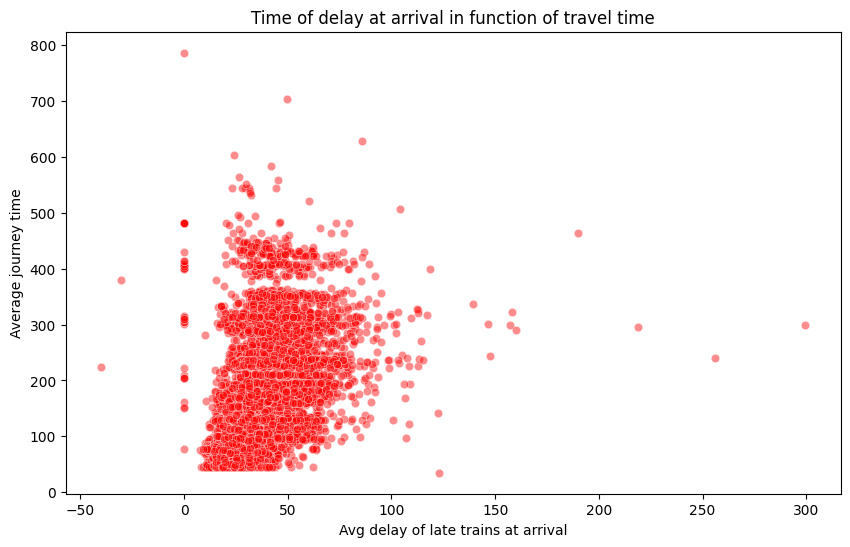

In [3615]:
#Size of graphic
plt.figure(figsize=(10, 6))

#Correlation between late of trains at arrival and journey time
sns.scatterplot(data=new, x='Average delay of late trains at arrival', y='Average journey time', alpha=0.45, color='red')
plt.title('Time of delay at arrival in function of travel time')
plt.xlabel('Avg delay of late trains at arrival')
plt.ylabel('Average journey time')
plt.show()

**Conclusion**

We can observe that:
- The data points are heavily concentrated between 0 and 1h10 of average arrival delay and between 0 and 7h30 of average journey time.
- There are extreme values ​​(such as trains with an average journey time of 13 hours, or negative delays).
- Therefore, there is no real correlation between average journey times and average arrival delays.
- There's a train with almost 800 minutes (13h20) of travel time, it's an extreme value.

In [3616]:
new = remove_extremes(new, "Average journey time")
new = remove_extremes(new, "Average delay of late trains at arrival")

#Drop lines with no number of scheduled trains because it's an important data
new.drop(new[new["Number of scheduled trains"].isna()].index, inplace=True)

### Corellation between number of delayed trains at departure and their averages

We need to check the correlation between these two columns and if there's any extreme values.

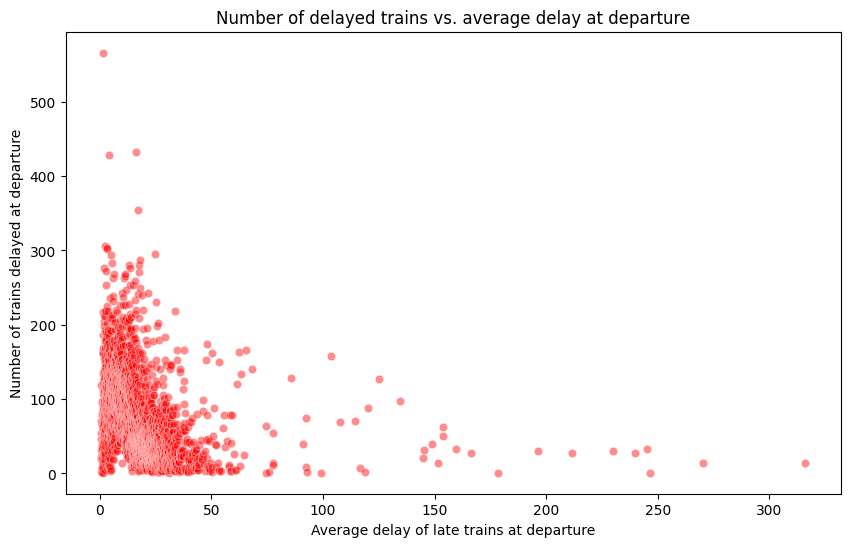

In [3617]:
#Size of graphic
plt.figure(figsize=(10, 6))

#Group lines in function of averages of delay of late train at departure, but mean only fot number of trains delayed at departure
temp = new.groupby(["Average delay of late trains at departure"]).aggregate({"Number of trains delayed at departure": "mean"})

#Correlation between late of trains at departure and number of trains
sns.scatterplot(data=temp, x='Average delay of late trains at departure', y='Number of trains delayed at departure', alpha=0.45, color='red')
plt.title('Number of delayed trains vs. average delay at departure')
plt.show()

**Conclusion**

We can observe that:
- The number of trains delayed and the average late delay at arrival are related, which is logical.
- The most of the delays are short (less than 50 min in average), so most of the trains have short delays.
- There's some **extreme values** with trains that have more than 200 (13 hours and 19 minutes) delays, or some stations that have more than 300 trains delayed at departure.

In [3618]:
new = remove_extremes(new, "Average delay of late trains at departure")
new = remove_extremes(new, "Number of trains delayed at departure")

#Drop lines with too high averages delays and number of trains after a first cleaning
new.drop(new[new["Average delay of late trains at departure"] > 200].index, inplace=True)
new.drop(new[new["Number of trains delayed at departure"] > 300].index, inplace=True)

### Corellation between number of delayed trains at arrival and their averages

We need to check the correlation between these two columns and if there's any extreme values.

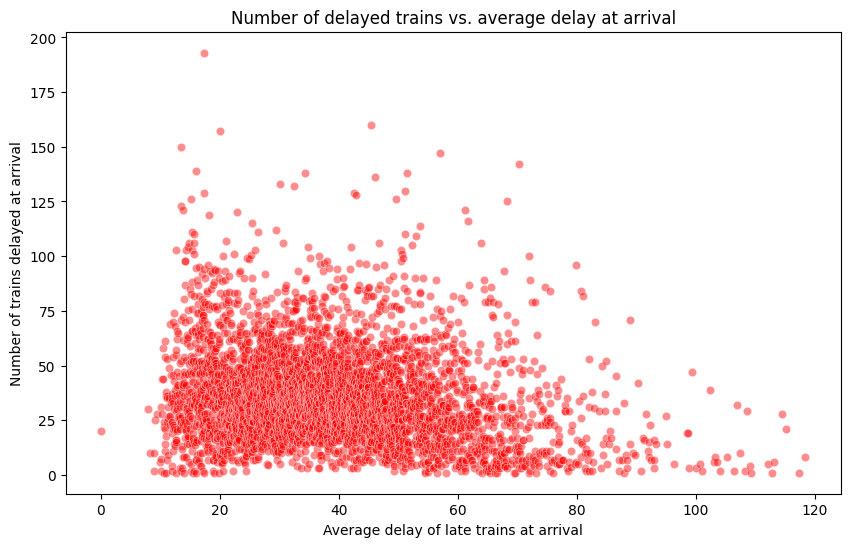

In [3619]:
#Size of graphic
plt.figure(figsize=(10, 6))

#Group lines in function of averages of delay of late train at arrival, but mean only fot number of trains delayed at arrival
temp = new.groupby(["Average delay of late trains at arrival"]).aggregate({"Number of trains delayed at arrival": "mean"})

#Correlation between late of trains at arrival and number of trains
sns.scatterplot(data=temp, x='Average delay of late trains at arrival', y='Number of trains delayed at arrival', alpha=0.45, color='red')
plt.title('Number of delayed trains vs. average delay at arrival')
plt.show()

**Conclusion**

We can observe that:
- The number of trains delayed and the average late delay at arrival are related, which is logical.
- Most of the delays at arrival are concentrated between 0 and 100 minutes, so most trains have relatively short delays.
- There are some **extreme values** with trains that have more than 200 minutes of average delay at arrival, or some records showing more than 180 trains delayed at arrival.
- There is also negative values, but they're only 2.

In [3620]:
new = remove_extremes(new, "Average delay of late trains at arrival")
new = remove_extremes(new, "Number of trains delayed at arrival")

#Remove averages negatives and > 150 and number of trains delayed > 180 after a first try of removing extremes values
new.drop(new[(new["Average delay of late trains at arrival"] < 0) | (new["Average delay of late trains at arrival"] > 150)].index, inplace=True)
new.drop(new[(new["Number of trains delayed at arrival"] > 180)].index, inplace=True)

We add a new column to know the mean delay during the previous month

In [ ]:
#We arrange the rows by train journey (Departure and Arrival), then chronologically by year and month.
new = new.sort_values(by=['Departure station', 'Arrival station', 'Year', 'Month'])

#Creates a new column with the previous month's average delay for each journey.
new['Delay previous month'] = new.groupby(['Departure station', 'Arrival station'])['Average delay of all trains at arrival'].shift(1)

#We remove every empty rows
new = new.dropna(subset=['Delay previous month'])

## Exporting the cleaned dataset after observations

In [3622]:
new.to_csv("cleaned_dataset.csv", sep=";", index=False)

# Bilan of the second step

- 